## NMF Analysis

This notebook loads the processed motor dataset, normalizes features to a common scale, and prepares the matrix for NMF.

In [5]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Config
df = pd.read_csv('processed_motor_data.csv')


df

,time (s),Protein Concentration_nM,vorticity [1/s]_mean,divergence [1/s]_mean,velocity magnitude [m/s]_mean,distance [m]_mean,power [W]_mean,shear [1/s]_mean,strain [1/s]_mean,correlation length [m]_mean,work [J]_mean,protein,DNA nM,Translation Rate [nM/s],velocity magnitude [m/s]_dt,correlation length [m]_dt,condition
0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,4.253997e-07,NaN,NaN,A,20.0,NaN,-2.332396e-12,3.391464e-08,A-20.0nM
1,2400.0,9.543904,NaN,NaN,NaN,NaN,NaN,NaN,1.964896e-08,NaN,NaN,A,20.0,0.003977,-2.454862e-12,3.258807e-08,A-20.0nM
2,4800.0,23.857011,NaN,NaN,NaN,NaN,NaN,NaN,-1.648674e-07,NaN,NaN,A,20.0,0.005964,-1.334657e-12,2.705877e-08,A-20.0nM
3,7200.0,38.853353,NaN,NaN,NaN,NaN,NaN,NaN,1.450093e-07,NaN,NaN,A,20.0,0.006248,-1.455120e-13,1.790595e-08,A-20.0nM
4,9600.0,54.337879,NaN,NaN,NaN,NaN,NaN,NaN,8.677084e-08,NaN,NaN,A,20.0,0.006452,-3.304482e-13,8.820600e-09,A-20.0nM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61433,124470.0,1859.908327,NaN,NaN,NaN,NaN,NaN,NaN,-2.020003e-08,NaN,NaN,Unc,80.0,-0.001563,8.098690e-13,-1.377275e-08,Unc-80.0nM
61434,124740.0,1860.127824,NaN,NaN,NaN,NaN,NaN,NaN,-2.045454e-08,NaN,NaN,Unc,80.0,0.000813,3.959140e-13,-1.389472e-08,Unc-80.0nM
61435,125010.0,1856.236436,NaN,NaN,NaN,NaN,NaN,NaN,2.304485e-09,NaN,NaN,Unc,80.0,-0.014413,-7.854898e-13,-1.392446e-08,Unc-80.0nM
61436,125280.0,1856.910592,NaN,NaN,NaN,NaN,NaN,NaN,1.417665e-08,NaN,NaN,Unc,80.0,0.002497,-2.853275e-13,-1.384950e-08,Unc-80.0nM


In [6]:
# included_prefixes = ['A', 'HeAl', 'ThTr']
# df = df[df['protein'].isin(included_prefixes)]
included_motors = list(df['condition'].unique())
included_motors

['A-20.0nM',
 'A-40.0nM',
 'A-80.0nM',
 'A-160.0nM',
 'AcSu-160.0nM',
 'AcSu2-1.25nM',
 'AcSu2-2.5nM',
 'AcSu2-5.0nM',
 'AcSu2-10.0nM',
 'AcSu2-20.0nM',
 'AcSu2-40.0nM',
 'AcSu2-80.0nM',
 'AcSu2-160.0nM',
 'AdPa-1.25nM',
 'AdPa-2.5nM',
 'AdPa-5.0nM',
 'AdPa-10.0nM',
 'AdPa-20.0nM',
 'AdPa-40.0nM',
 'AdPa-80.0nM',
 'AdPa-160.0nM',
 'B-1.25nM',
 'B-2.5nM',
 'B-5.0nM',
 'B-10.0nM',
 'B-20.0nM',
 'B-40.0nM',
 'B-80.0nM',
 'B-160.0nM',
 'C-1.25nM',
 'C-2.5nM',
 'C-5.0nM',
 'C-10.0nM',
 'C-20.0nM',
 'C-40.0nM',
 'C-80.0nM',
 'C-160.0nM',
 'D-1.25nM',
 'D-2.5nM',
 'D-5.0nM',
 'D-10.0nM',
 'D-20.0nM',
 'D-40.0nM',
 'D-80.0nM',
 'D-160.0nM',
 'DiPu-1.25nM',
 'DiPu-2.5nM',
 'DiPu-5.0nM',
 'DiPu-10.0nM',
 'DiPu-20.0nM',
 'DiPu-40.0nM',
 'DiPu-80.0nM',
 'DiPu-160.0nM',
 'F-1.25nM',
 'F-2.5nM',
 'F-5.0nM',
 'F-10.0nM',
 'F-20.0nM',
 'F-40.0nM',
 'F-80.0nM',
 'F-160.0nM',
 'G-1.25nM',
 'G-2.5nM',
 'G-5.0nM',
 'G-10.0nM',
 'G-20.0nM',
 'G-40.0nM',
 'G-80.0nM',
 'G-160.0nM',
 'H-1.25nM',
 'H-2.5nM',
 

In [7]:

# included_motors = [
#     'A-20.0nM',
#     'A-40.0nM',
#     'A-80.0nM',
#     'A-160.0nM',

#     # 'C-1.25nM',
#     # 'C-2.5nM',
#     'C-5.0nM',
#     'C-10.0nM',
#     'C-20.0nM',
#     'C-40.0nM',
#     'C-80.0nM',
#     'C-160.0nM',

#     'D-1.25nM',
#     'D-2.5nM',
#     'D-5.0nM',
#     'D-10.0nM',
#     'D-20.0nM',
#     'D-40.0nM',
#     'D-80.0nM',
#     'D-160.0nM',

#     # 'G-1.25nM',
#     # 'G-2.5nM',
#     'G-5.0nM',
#     'G-10.0nM',
#     'G-20.0nM',
#     'G-40.0nM',
#     'G-80.0nM',
#     'G-160.0nM',

#     'H-1.25nM',
#     'H-2.5nM',
#     'H-5.0nM',
#     'H-10.0nM',
#     'H-20.0nM',
#     'H-40.0nM',
#     'H-80.0nM',
#     'H-160.0nM',

#     # 'AcSu-160.0nM',
#     # 'AcSu2-1.25nM',
#     # 'AcSu2-2.5nM',
#     # 'AcSu2-5.0nM',
#     # # 'AcSu2-10.0nM',
#     # # 'AcSu2-20.0nM',
#     # # 'AcSu2-40.0nM',
#     # # 'AcSu2-80.0nM',
#     # 'AcSu2-160.0nM',

#     # # 'AdPa-1.25nM',
#     # # 'AdPa-2.5nM',
#     # 'AdPa-5.0nM',
#     # 'AdPa-10.0nM',
#     # # 'AdPa-20.0nM',
#     # # 'AdPa-40.0nM',
#     # # # 'AdPa-80.0nM',
#     # 'AdPa-160.0nM',

#     # 'DiPu-1.25nM',
#     # 'DiPu-2.5nM',
#     # 'DiPu-5.0nM',
#     # 'DiPu-10.0nM',
#     # 'DiPu-20.0nM',
#     # 'DiPu-40.0nM',
#     # 'DiPu-80.0nM',
#     # 'DiPu-160.0nM',

#     # 'TiLa-160.0nM',

#     'HeAl-1.25nM',
#     'HeAl-2.5nM',
#     'HeAl-5.0nM',
#     'HeAl-10.0nM',
#     'HeAl-20.0nM',
#     'HeAl-40.0nM',
#     'HeAl-80.0nM',
#     'HeAl-160.0nM',

#     # 'Kif5-160.0nM',

#     'NaGr-1.25nM',
#     'NaGr-2.5nM',
#     'NaGr-5.0nM',
#     'NaGr-10.0nM',
#     'NaGr-20.0nM',
#     'NaGr-40.0nM',
#     'NaGr-80.0nM',
#     'NaGr-160.0nM',

#     'ThTr-1.25nM',
#     'ThTr-2.5nM',
#     'ThTr-5.0nM',
#     'ThTr-10.0nM',
#     'ThTr-20.0nM',
#     'ThTr-40.0nM',
#     'ThTr-80.0nM',
#     'ThTr-160.0nM',

#     'Unc-10.0nM',
#     'Unc-20.0nM',
#     'Unc-40.0nM',
#     'Unc-80.0nM'
#  ]




In [8]:

included_motors = [
    'A-20.0nM',
    'A-40.0nM',
    'A-80.0nM',
    'A-160.0nM',

    # 'C-1.25nM',
    # 'C-2.5nM',
    'C-5.0nM',
    'C-10.0nM',
    'C-20.0nM',
    'C-40.0nM',
    'C-80.0nM',
    'C-160.0nM',

    'D-1.25nM',
    'D-2.5nM',
    'D-5.0nM',
    'D-10.0nM',
    'D-20.0nM',
    'D-40.0nM',
    'D-80.0nM',
    'D-160.0nM',

    # 'G-1.25nM',
    # 'G-2.5nM',
    'G-5.0nM',
    'G-10.0nM',
    'G-20.0nM',
    'G-40.0nM',
    'G-80.0nM',
    'G-160.0nM',

    'H-1.25nM',
    'H-2.5nM',
    'H-5.0nM',
    'H-10.0nM',
    'H-20.0nM',
    'H-40.0nM',
    'H-80.0nM',
    'H-160.0nM',

    # 'AcSu-160.0nM',
    # 'AcSu2-1.25nM',
    # 'AcSu2-2.5nM',
    # 'AcSu2-5.0nM',
    # # 'AcSu2-10.0nM',
    # # 'AcSu2-20.0nM',
    # # 'AcSu2-40.0nM',
    # # 'AcSu2-80.0nM',
    # 'AcSu2-160.0nM',

    # # 'AdPa-1.25nM',
    # # 'AdPa-2.5nM',
    # 'AdPa-5.0nM',
    # 'AdPa-10.0nM',
    # # 'AdPa-20.0nM',
    # # 'AdPa-40.0nM',
    # # # 'AdPa-80.0nM',
    # 'AdPa-160.0nM',

    # # 'DiPu-1.25nM',
    # 'DiPu-2.5nM',
    # 'DiPu-5.0nM',
    # 'DiPu-10.0nM',
    # 'DiPu-20.0nM',
    # 'DiPu-40.0nM',
    # 'DiPu-80.0nM',
    # 'DiPu-160.0nM',

    # # 'TiLa-160.0nM',

    'HeAl-1.25nM',
    'HeAl-2.5nM',
    'HeAl-5.0nM',
    'HeAl-10.0nM',
    'HeAl-20.0nM',
    'HeAl-40.0nM',
    'HeAl-80.0nM',
    'HeAl-160.0nM',

    # # 'Kif5-160.0nM',

    'NaGr-1.25nM',
    'NaGr-2.5nM',
    'NaGr-5.0nM',
    'NaGr-10.0nM',
    'NaGr-20.0nM',
    'NaGr-40.0nM',
    'NaGr-80.0nM',
    'NaGr-160.0nM',

    'ThTr-1.25nM',
    'ThTr-2.5nM',
    'ThTr-5.0nM',
    'ThTr-10.0nM',
    'ThTr-20.0nM',
    'ThTr-40.0nM',
    'ThTr-80.0nM',
    'ThTr-160.0nM',

    'Unc-10.0nM',
    'Unc-20.0nM',
    'Unc-40.0nM',
    'Unc-80.0nM'
 ]




In [9]:
# Remove proteins not in included_motors
df = df[df['condition'].isin(included_motors)]

In [10]:
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import StandardScaler

# ---------- Feature dictionary with gaussian filter sigma ----------
features_and_sigmas = {
    'velocity magnitude [m/s]_mean':   1.0,
    # 'vorticity [1/s]_mean':            1.5,
    # 'divergence [1/s]_mean':           1.5,
    # 'Protein Concentration_nM':        1.0,
    'Translation Rate [nM/s]':         1.0,
    'correlation length [m]_mean':     1.0,
    # 'power [W]_mean':                  0.5,
    # 'shear [1/s]_mean':                1.0,
    # 'strain [1/s]_mean':               1.0,
    # 'velocity magnitude [m/s]_dt':     1.0,
    # 'correlation length [m]_dt':       1.0,
}

SIGNED_FEATURES = {
    'vorticity [1/s]_mean',
    'divergence [1/s]_mean',
}

features = list(features_and_sigmas.keys())
APPLY_ZSCORE = True  # True = z-score per feature block; False = raw (still shifted to >=0)

print("Creating multi-feature matrix for NMF analysis...")
print("Features and gaussian sigmas (for smoothing):")
for f, sigma in features_and_sigmas.items():
    print(f"  {f}: gaussian_sigma={sigma}")
print("Applying Z-score standardization" if APPLY_ZSCORE else "Using raw feature values (no standardization)")

# --- Preparation ---
all_conditions = sorted(df['condition'].dropna().unique().tolist())
print(f"Total unique conditions: {len(all_conditions)}")

common_time_index = np.sort(df['time (s)'].dropna().unique())
common_time_index = pd.Index(common_time_index, name='time (s)')
print(f"Total unique time points: {len(common_time_index)}")

def _interp_to_common_time(s: pd.Series, common_idx: pd.Index) -> pd.Series:
    """
    Interpolate ONLY within the observed time range for that condition.
    Outside the observed range -> NaN (no invented signal).
    """
    s = s.sort_index()
    s_valid = s.dropna()
    out = pd.Series(np.nan, index=common_idx, dtype=float)

    if s_valid.empty:
        return out

    x = s_valid.index.to_numpy(dtype=float)
    y = s_valid.to_numpy(dtype=float)
    t = common_idx.to_numpy(dtype=float)

    inside = (t >= x.min()) & (t <= x.max())
    if np.any(inside):
        out.iloc[np.where(inside)[0]] = np.interp(t[inside], x, y)

    return out

def _smooth_ignore_missing(col: pd.Series, sigma: float) -> pd.Series:
    """
    Smooth a single time-series. We avoid smoothing NaNs by filling them
    with nearest values ONLY for the smoothing operation, then restoring NaNs.
    """
    if sigma <= 0:
        return col

    arr = col.to_numpy(dtype=float)
    nanmask = ~np.isfinite(arr)

    if nanmask.all():
        return col

    # Fill NaNs for smoothing
    filled = pd.Series(arr).interpolate(limit_direction="both").to_numpy(dtype=float)
    sm = gaussian_filter1d(filled, sigma=float(sigma), mode="nearest")

    sm[nanmask] = np.nan
    return pd.Series(sm, index=col.index)

def _make_nonneg_for_nmf(mat: pd.DataFrame, feature_name: str) -> dict[str, pd.DataFrame]:
    """
    NMF requires nonnegative inputs.
    - For signed features: split into pos/neg channels (no information destruction).
    - For non-signed features: shift to >=0 if needed.
    """
    if feature_name in SIGNED_FEATURES:
        pos = mat.clip(lower=0)
        neg = (-mat).clip(lower=0)
        return {f"{feature_name}__pos": pos, f"{feature_name}__neg": neg}

    min_val = float(np.nanmin(mat.to_numpy()))
    if min_val < 0:
        mat = mat - min_val
    return {feature_name: mat}

# Second pass: pivot -> interpolate -> smooth -> fill missing -> make nonneg
expanded_feature_matrices: dict[str, pd.DataFrame] = {}

for feature in features:
    print(f"Processing {feature}...")

    pivot = df.pivot_table(
        index='time (s)',
        columns='condition',
        values=feature,
        aggfunc='mean'
    ).reindex(index=common_time_index, columns=all_conditions)

    interp = pd.DataFrame(index=common_time_index, columns=all_conditions, dtype=float)
    for c in all_conditions:
        interp[c] = _interp_to_common_time(pivot[c], common_time_index)

    sigma = float(features_and_sigmas[feature])
    if sigma > 0:
        for c in all_conditions:
            interp[c] = _smooth_ignore_missing(interp[c], sigma)
        print(f"  Applied gaussian_filter1d with sigma={sigma:.2f}")

    # Fill remaining NaNs with feature median (NOT 0)
    if interp.isna().any().any():
        med = float(np.nanmedian(interp.to_numpy()))
        interp = interp.fillna(med)

    parts = _make_nonneg_for_nmf(interp, feature)
    for name, mat in parts.items():
        expanded_feature_matrices[name] = mat
        print(f"  {name} matrix shape: {mat.shape}")

# --- Feature Scaling + Block normalization ---
scaled_feature_matrices: dict[str, np.ndarray] = {}
scalers: dict[str, StandardScaler | None] = {}

if APPLY_ZSCORE:
    print("\nApplying Z-score standardization to each feature block (then shifting to >=0, then block-normalizing)...")
    for feature_name, mat in expanded_feature_matrices.items():
        print(f"Scaling {feature_name}...")

        scaler = StandardScaler()
        X = scaler.fit_transform(mat.to_numpy(dtype=float))

        # Guardrail: cap extreme Z values (prevents tiny-variance noise from exploding)
        X = np.clip(X, -8, 8)

        # Shift to >=0 for NMF
        min_val = float(X.min())
        if min_val < 0:
            X = X - min_val

        # # Block Frobenius normalization (equalize each feature block contribution)
        fro = float(np.linalg.norm(X, ord="fro")) + 1e-12
        X = X / fro

        scaled_feature_matrices[feature_name] = X
        scalers[feature_name] = scaler

        print(f"  Scaled+shifted+normed range: [{X.min():.3f}, {X.max():.3f}]")
else:
    print("\nUsing raw feature values (shifted to >=0 if needed, then block-normalizing)...")
    for feature_name, mat in expanded_feature_matrices.items():
        X = mat.to_numpy(dtype=float)

        min_val = float(X.min())
        if min_val < 0:
            X = X - min_val

        fro = float(np.linalg.norm(X, ord="fro")) + 1e-12
        X = X / fro

        scaled_feature_matrices[feature_name] = X
        scalers[feature_name] = None

        print(f"  {feature_name} normed range: [{X.min():.3e}, {X.max():.3e}]")

# Combine all scaled features into a single matrix: (feature_block*time) x conditions
ordered_feature_names = list(scaled_feature_matrices.keys())
print(f"\nCombining {len(ordered_feature_names)} scaled feature blocks into single matrix...")
combined_matrix = np.vstack([scaled_feature_matrices[name] for name in ordered_feature_names])

multi_feature_matrix = combined_matrix
feature_names = ordered_feature_names
time_index = common_time_index
condition_columns = all_conditions

print(f"\nMulti-feature matrix ready for NMF analysis!")
print(f"Matrix shape: {multi_feature_matrix.shape}")
print(f"Min value: {multi_feature_matrix.min():.6f}")
print(f"Max value: {multi_feature_matrix.max():.6f}")
print(f"Mean value: {multi_feature_matrix.mean():.6f}")
print(f"Std value: {multi_feature_matrix.std():.6f}")

Creating multi-feature matrix for NMF analysis...
Features and gaussian sigmas (for smoothing):
  velocity magnitude [m/s]_mean: gaussian_sigma=1.0
  Translation Rate [nM/s]: gaussian_sigma=1.0
  correlation length [m]_mean: gaussian_sigma=1.0
Applying Z-score standardization
Total unique conditions: 60
Total unique time points: 4962
Processing velocity magnitude [m/s]_mean...
  Applied gaussian_filter1d with sigma=1.00
  velocity magnitude [m/s]_mean matrix shape: (4962, 60)
Processing Translation Rate [nM/s]...
  Applied gaussian_filter1d with sigma=1.00
  Translation Rate [nM/s] matrix shape: (4962, 60)
Processing correlation length [m]_mean...
  Applied gaussian_filter1d with sigma=1.00
  correlation length [m]_mean matrix shape: (4962, 60)

Applying Z-score standardization to each feature block (then shifting to >=0, then block-normalizing)...
Scaling velocity magnitude [m/s]_mean...
  Scaled+shifted+normed range: [0.000, 0.004]
Scaling Translation Rate [nM/s]...
  Scaled+shifted+

In [11]:
from joblib import Parallel, delayed
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error
import numpy as np

print("Setting up NMF reconstruction error analysis for multi-feature data...")

# Choose component range
max_components = min(15, min(multi_feature_matrix.shape))
# Start at 2 by default (1 is usually not informative and skews elbow heuristics)
n_components_range = range(2, max_components + 1)

print(f"Testing NMF with component counts: {list(n_components_range)}")
print(f"Matrix dimensions: {multi_feature_matrix.shape[0]} rows × {multi_feature_matrix.shape[1]} columns")
print(f"Features included: {feature_names}")
print(f"Maximum possible components: {min(multi_feature_matrix.shape)} (capped at {max_components})")

# --- Metrics storage ---
reconstruction_mse = []
reconstruction_rel_mse = []  # scale-free: MSE / mean(X^2)

X = np.asarray(multi_feature_matrix, dtype=float)
X_energy = float(np.mean(X * X)) + 1e-12  # avoid divide-by-zero

def compute_nmf_metrics(k: int):
    # Deterministic init greatly improves stability
    nmf = NMF(
        n_components=k,
        init="nndsvda",      # better than random
        solver="cd",
        beta_loss="frobenius",
        max_iter=4000,       # 1000 often not enough
        tol=1e-5,
        random_state=42
    )

    W = nmf.fit_transform(X)
    H = nmf.components_
    Xhat = W @ H

    mse = mean_squared_error(X.ravel(), Xhat.ravel())
    rel = mse / X_energy
    return k, mse, rel, nmf.n_iter_

print("\nComputing reconstruction errors for different numbers of components...")

results = Parallel(n_jobs=-1, backend="loky")(
    delayed(compute_nmf_metrics)(k) for k in n_components_range
)

# Ensure results are sorted (Parallel can return out of order)
results.sort(key=lambda t: t[0])

for k, mse, rel, n_iter in results:
    reconstruction_mse.append(mse)
    reconstruction_rel_mse.append(rel)
    print(f"  k={k:2d} -> MSE: {mse:.3e}, RelMSE: {rel:.3e}, iters: {n_iter}")

print("\nReconstruction error analysis complete!")

Setting up NMF reconstruction error analysis for multi-feature data...
Testing NMF with component counts: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Matrix dimensions: 14886 rows × 60 columns
Features included: ['velocity magnitude [m/s]_mean', 'Translation Rate [nM/s]', 'correlation length [m]_mean']
Maximum possible components: 60 (capped at 15)

Computing reconstruction errors for different numbers of components...


/Users/dalarios/anaconda3/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 4000 reached. Increase it to improve convergence.
  warnings.warn(
/Users/dalarios/anaconda3/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 4000 reached. Increase it to improve convergence.
  warnings.warn(
/Users/dalarios/anaconda3/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 4000 reached. Increase it to improve convergence.
  warnings.warn(
/Users/dalarios/anaconda3/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 4000 reached. Increase it to improve convergence.
  warnings.warn(
/Users/dalarios/anaconda3/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 4000 reached. Increase it to imp

  k= 2 -> MSE: 8.066e-08, RelMSE: 2.401e-02, iters: 4000
  k= 3 -> MSE: 6.560e-08, RelMSE: 1.953e-02, iters: 4000
  k= 4 -> MSE: 5.442e-08, RelMSE: 1.620e-02, iters: 4000
  k= 5 -> MSE: 4.718e-08, RelMSE: 1.405e-02, iters: 4000
  k= 6 -> MSE: 4.150e-08, RelMSE: 1.236e-02, iters: 4000
  k= 7 -> MSE: 3.646e-08, RelMSE: 1.085e-02, iters: 4000
  k= 8 -> MSE: 3.219e-08, RelMSE: 9.583e-03, iters: 4000
  k= 9 -> MSE: 2.844e-08, RelMSE: 8.468e-03, iters: 4000
  k=10 -> MSE: 2.533e-08, RelMSE: 7.541e-03, iters: 4000
  k=11 -> MSE: 2.311e-08, RelMSE: 6.881e-03, iters: 4000
  k=12 -> MSE: 2.100e-08, RelMSE: 6.251e-03, iters: 4000
  k=13 -> MSE: 1.922e-08, RelMSE: 5.724e-03, iters: 4000
  k=14 -> MSE: 1.761e-08, RelMSE: 5.242e-03, iters: 4000
  k=15 -> MSE: 1.622e-08, RelMSE: 4.829e-03, iters: 4000

Reconstruction error analysis complete!


/Users/dalarios/anaconda3/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 4000 reached. Increase it to improve convergence.
  warnings.warn(


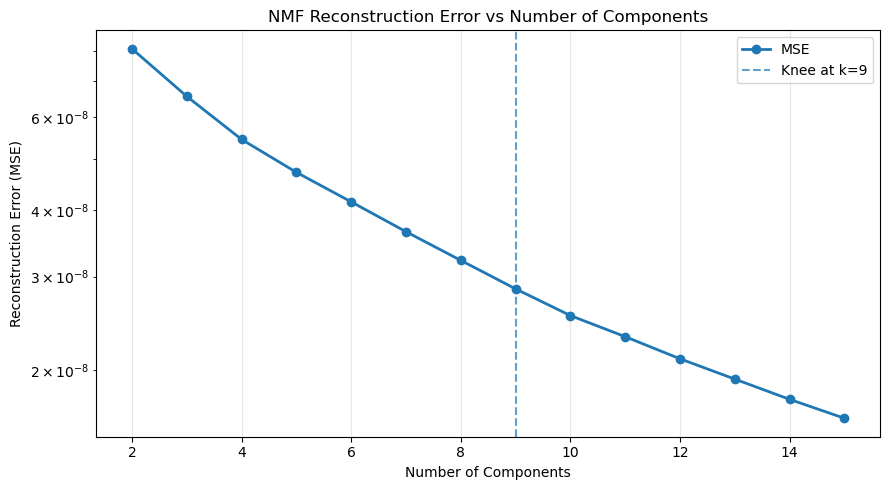


NMF COMPONENT SELECTION SUMMARY
Matrix dimensions: 14886 rows × 60 columns
Features: ['velocity magnitude [m/s]_mean', 'Translation Rate [nM/s]', 'correlation length [m]_mean']
Tested component range: 2 to 15

Recommended components (knee on log-MSE): 9

Final recommendation: Use k=9


In [12]:
import numpy as np
import matplotlib.pyplot as plt

k_list = list(n_components_range)
mse_list = list(reconstruction_mse)          # defined
rel_list = list(reconstruction_rel_mse)      # defined

def knee_by_chord(x_list, y_list):
    x = np.asarray(x_list, float)
    y = np.asarray(y_list, float)
    y = np.log(np.maximum(y, 1e-12))
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    v = p2 - p1
    v = v / (np.linalg.norm(v) + 1e-12)
    pts = np.c_[x, y]
    proj = ((pts - p1) @ v)
    orth = (pts - p1) - np.outer(proj, v)
    d = np.linalg.norm(orth, axis=1)
    return int(x[np.argmax(d)])

k_knee = knee_by_chord(k_list, mse_list)

fig, ax = plt.subplots(1, 1, figsize=(9, 5))
ax.plot(k_list, mse_list, 'o-', linewidth=2, markersize=6, label="MSE")
ax.set_xlabel("Number of Components")
ax.set_ylabel("Reconstruction Error (MSE)")
ax.set_title("NMF Reconstruction Error vs Number of Components")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.axvline(k_knee, linestyle="--", alpha=0.7, label=f"Knee at k={k_knee}")
ax.legend()
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("NMF COMPONENT SELECTION SUMMARY")
print("="*60)
print(f"Matrix dimensions: {multi_feature_matrix.shape[0]} rows × {multi_feature_matrix.shape[1]} columns")
print(f"Features: {feature_names}")
print(f"Tested component range: {min(k_list)} to {max(k_list)}")
print(f"\nRecommended components (knee on log-MSE): {k_knee}")
print(f"\nFinal recommendation: Use k={k_knee}")

In [13]:
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error
import numpy as np

# Choose component count from prior diagnostics
# You already computed this in the knee plot cell:
# k_knee = knee_by_chord(k_list, mse_list)
optimal_components = int(k_knee)

print(f"Performing NMF with k={optimal_components} components (knee-selected)")

X = np.asarray(multi_feature_matrix, dtype=float)

nmf_optimal = NMF(
    n_components=optimal_components,
    init="nndsvda",
    solver="cd",
    beta_loss="frobenius",
    max_iter=4000,
    tol=1e-5,
    random_state=42
)

W_optimal = nmf_optimal.fit_transform(X)
H_optimal = nmf_optimal.components_

print("NMF factorization complete!")
print(f"W shape (rows × components): {W_optimal.shape}")
print(f"H shape (components × conditions): {H_optimal.shape}")
print(f"Iterations used: {nmf_optimal.n_iter_}")

# Reconstruction error
Xhat = W_optimal @ H_optimal
final_mse = mean_squared_error(X.ravel(), Xhat.ravel())
print(f"Final reconstruction MSE: {final_mse:.3e}")

# Store results
nmf_results = {
    "n_components": optimal_components,
    "W": W_optimal,
    "H": H_optimal,
    "reconstruction_mse": final_mse,
    "model": nmf_optimal,
    "time_index": time_index,
    "condition_columns": condition_columns,
    "feature_names": feature_names,   # block names, including __pos/__neg
}

behavior_space = H_optimal.T  # shape: (n_conditions, k)
behavior_space_df = pd.DataFrame(
    behavior_space,
    index=condition_columns,
    columns=[f"comp_{i+1}" for i in range(optimal_components)]
)
display(behavior_space_df.head())

Performing NMF with k=9 components (knee-selected)
NMF factorization complete!
W shape (rows × components): (14886, 9)
H shape (components × conditions): (9, 60)
Iterations used: 4000
Final reconstruction MSE: 2.844e-08


/Users/dalarios/anaconda3/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1710: ConvergenceWarning: Maximum number of iterations 4000 reached. Increase it to improve convergence.
  warnings.warn(


,comp_1,comp_2,comp_3,comp_4,comp_5,comp_6,comp_7,comp_8,comp_9
A-160.0nM,0.054272,0.049530,0.017558,0.181227,0.007697,0.080637,0.005924,0.040001,0.032500
A-20.0nM,0.051842,0.017164,0.040567,0.121407,0.000000,0.170742,0.035391,0.028090,0.000000
A-40.0nM,0.060592,0.015200,0.040181,0.159816,0.006548,0.124522,0.023598,0.026496,0.015523
A-80.0nM,0.061045,0.034972,0.035553,0.175156,0.012145,0.072461,0.011112,0.031304,0.032098
C-10.0nM,0.101197,0.128057,0.011224,0.058219,0.013285,0.007121,0.019367,0.020107,0.018523


Visualizing NMF components (multi-feature patterns)...


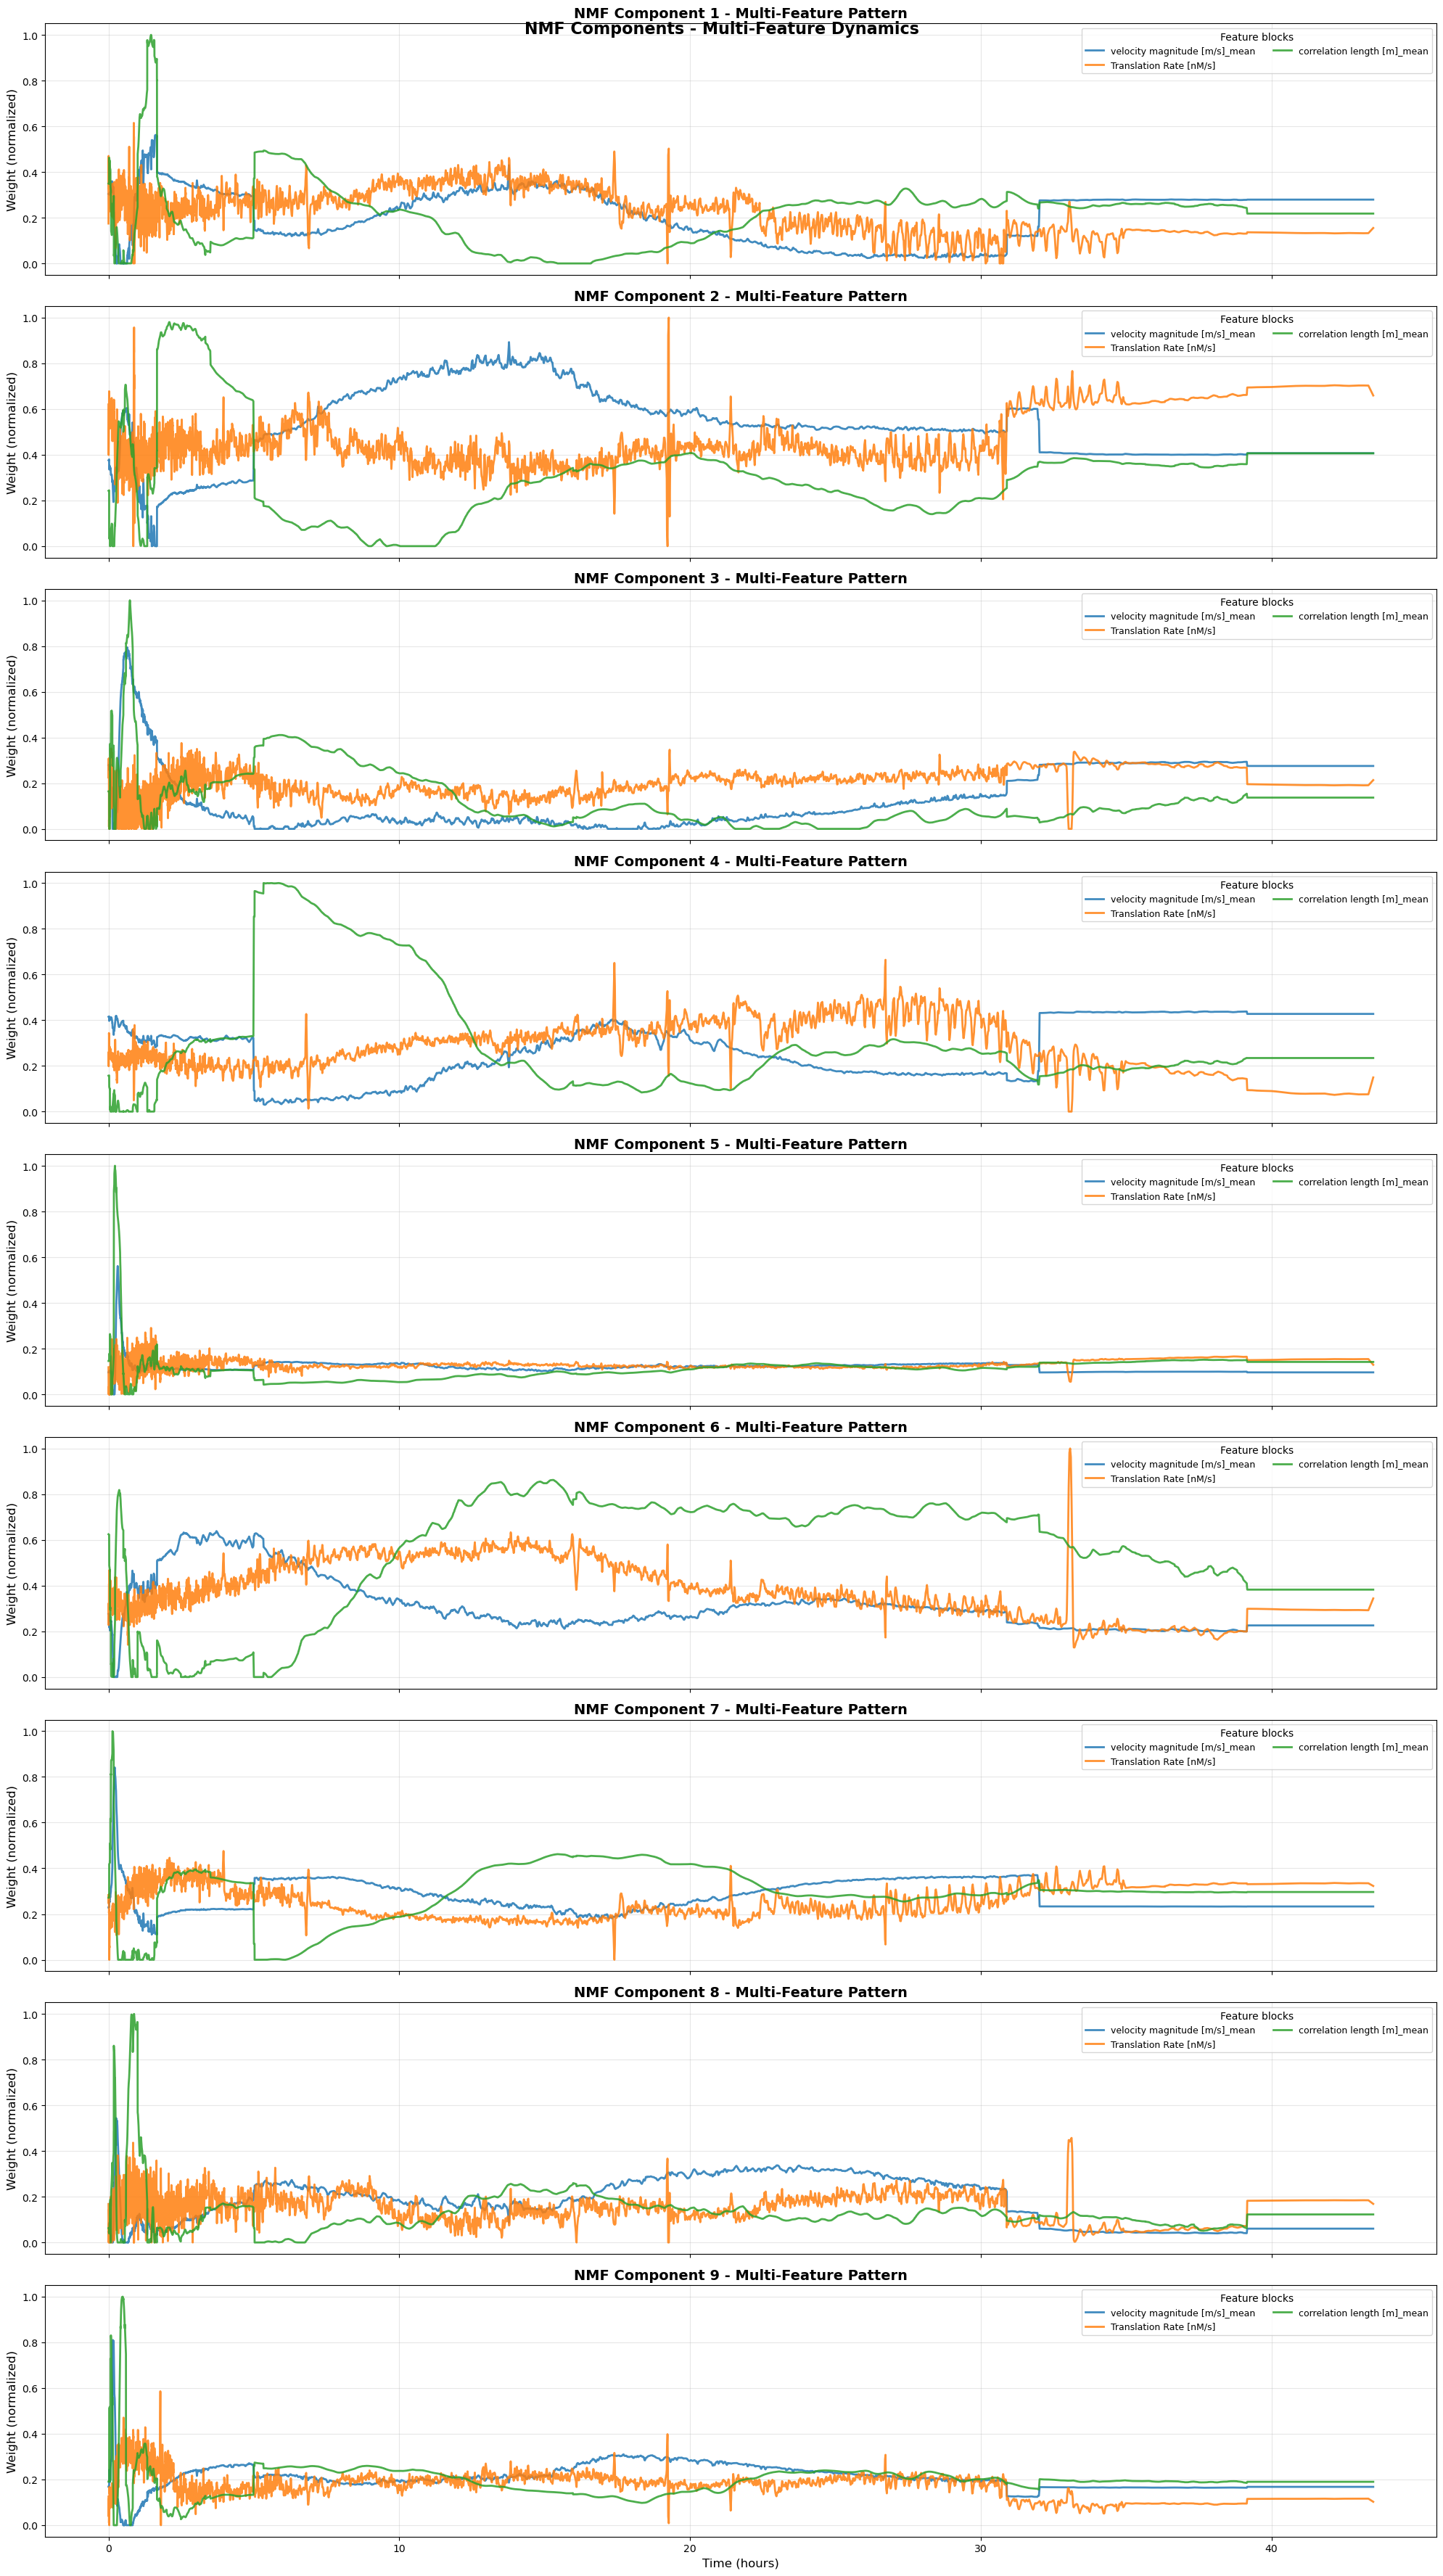

Multi-feature component visualization complete!


In [14]:
import numpy as np
import matplotlib.pyplot as plt

print("Visualizing NMF components (multi-feature patterns)...")

W = nmf_results["W"]                           # (n_blocks*n_time, k)
blocks = nmf_results["feature_names"]          # list of feature blocks (incl __pos/__neg)
time_s = np.asarray(nmf_results["time_index"], dtype=float)
k = int(nmf_results["n_components"])

n_time = len(time_s)
n_blocks = len(blocks)

expected_rows = n_blocks * n_time
if W.shape[0] != expected_rows:
    raise ValueError(
        f"W has {W.shape[0]} rows but expected {expected_rows} = {n_blocks}×{n_time}. "
        "This means the stacking order changed or time_index doesn't match."
    )

# reshape to: blocks × time × components
W_bt_k = W.reshape(n_blocks, n_time, k)
time_hours = time_s / 3600.0

NORMALIZE_FOR_PLOT = True

fig, axes = plt.subplots(k, 1, figsize=(20, 4 * k), sharex=True)
if k == 1:
    axes = [axes]

for i in range(k):
    ax = axes[i]
    curves = W_bt_k[:, :, i].copy()  # blocks × time

    if NORMALIZE_FOR_PLOT:
        denom = np.max(curves)
        if denom > 0:
            curves = curves / denom

    for j, name in enumerate(blocks):
        ax.plot(time_hours, curves[j, :], linewidth=2, alpha=0.85, label=name)

    ax.set_title(f"NMF Component {i+1} - Multi-Feature Pattern", fontsize=14, fontweight="bold")
    ax.set_ylabel("Weight (normalized)" if NORMALIZE_FOR_PLOT else "Weight", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(title="Feature blocks", fontsize=9, ncol=2)

axes[-1].set_xlabel("Time (hours)", fontsize=12)
plt.suptitle("NMF Components - Multi-Feature Dynamics", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

print("Multi-feature component visualization complete!")

Silhouette by #clusters:
  k=2: silhouette=0.216
  k=3: silhouette=0.256
  k=4: silhouette=0.293
  k=5: silhouette=0.309
  k=6: silhouette=0.316
  k=7: silhouette=0.323
  k=8: silhouette=0.289
  k=9: silhouette=0.295
  k=10: silhouette=0.313

Chosen #clusters = 7 (best silhouette=0.323)


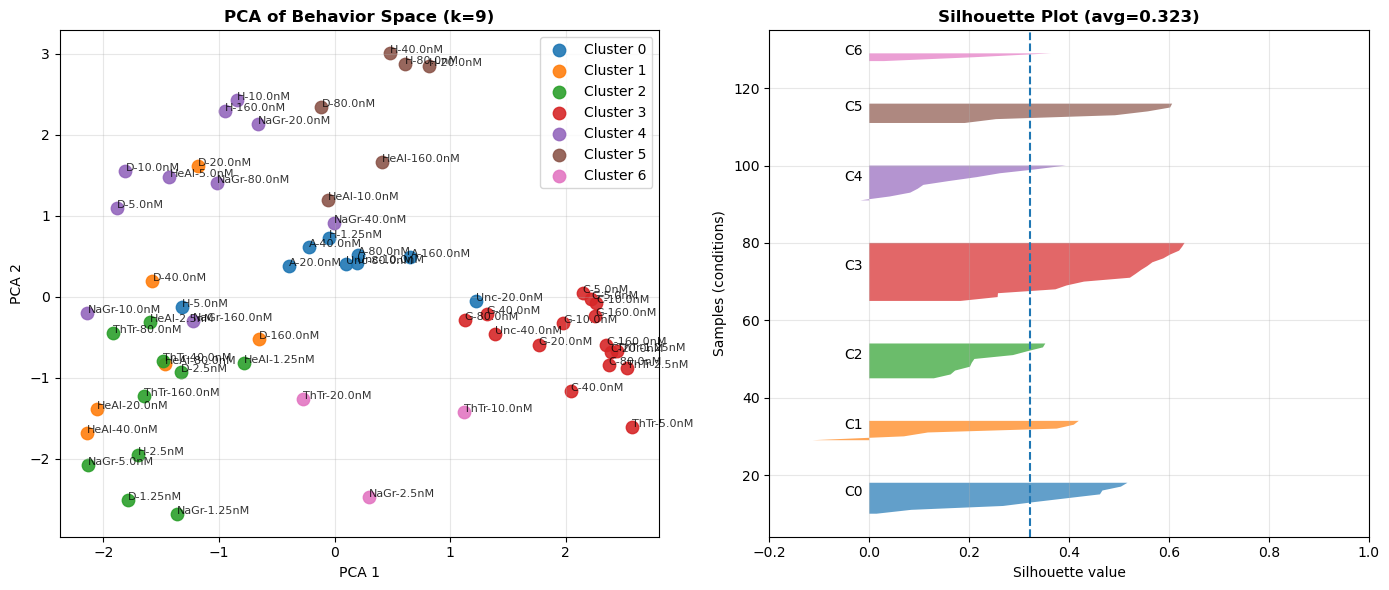


Stored clustering outputs in `cluster_results`.


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# ------------- Step A: prepare behavior space -------------
Xc = behavior_space_df.to_numpy(dtype=float)

# Standardize columns for clustering (important)
Xc_z = StandardScaler().fit_transform(Xc)

# ------------- Step B: choose number of clusters by silhouette -------------
cluster_range = range(2, min(10, Xc_z.shape[0]-1) + 1)  # 2..up to 10 or n-1
sil_by_k = []

best = {"k": None, "score": -np.inf, "labels": None}

for k in cluster_range:
    km = KMeans(n_clusters=k, n_init=50, random_state=42)
    labels = km.fit_predict(Xc_z)
    score = silhouette_score(Xc_z, labels)
    sil_by_k.append((k, score))
    if score > best["score"]:
        best = {"k": k, "score": score, "labels": labels}

print("Silhouette by #clusters:")
for k, s in sil_by_k:
    print(f"  k={k}: silhouette={s:.3f}")

print(f"\nChosen #clusters = {best['k']} (best silhouette={best['score']:.3f})")

labels = best["labels"]
sil_vals = silhouette_samples(Xc_z, labels)

# ------------- Step C: 2D embedding for plotting (UMAP if available, PCA fallback) -------------
try:
    import umap
    embedder = umap.UMAP(n_neighbors=8, min_dist=0.1, random_state=42)
    emb2 = embedder.fit_transform(Xc_z)
    emb_name = "UMAP"
except Exception:
    from sklearn.decomposition import PCA
    emb2 = PCA(n_components=2, random_state=42).fit_transform(Xc_z)
    emb_name = "PCA"

plot_df = pd.DataFrame({
    "x": emb2[:, 0],
    "y": emb2[:, 1],
    "cluster": labels,
    "silhouette": sil_vals,
}, index=behavior_space_df.index)

# ------------- Step D: plot (scatter + silhouette bar) -------------
fig, (ax_scatter, ax_sil) = plt.subplots(1, 2, figsize=(14, 6))

# scatter colored by cluster
for c in np.unique(labels):
    sub = plot_df[plot_df["cluster"] == c]
    ax_scatter.scatter(sub["x"], sub["y"], s=80, alpha=0.9, label=f"Cluster {c}")

# annotate points with condition names (optional: can be noisy)
ANNOTATE = True
if ANNOTATE:
    for name, row in plot_df.iterrows():
        ax_scatter.text(row["x"], row["y"], str(name), fontsize=8, alpha=0.8)

ax_scatter.set_title(f"{emb_name} of Behavior Space (k={optimal_components})", fontweight="bold")
ax_scatter.set_xlabel(f"{emb_name} 1")
ax_scatter.set_ylabel(f"{emb_name} 2")
ax_scatter.grid(True, alpha=0.3)
ax_scatter.legend()

# silhouette plot
y_lower = 10
for c in np.unique(labels):
    vals = np.sort(plot_df.loc[plot_df["cluster"] == c, "silhouette"].to_numpy())
    size = len(vals)
    y_upper = y_lower + size
    ax_sil.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7)
    ax_sil.text(-0.05, y_lower + 0.5 * size, f"C{c}", fontsize=10)
    y_lower = y_upper + 10

ax_sil.axvline(best["score"], linestyle="--")
ax_sil.set_title(f"Silhouette Plot (avg={best['score']:.3f})", fontweight="bold")
ax_sil.set_xlabel("Silhouette value")
ax_sil.set_ylabel("Samples (conditions)")
ax_sil.set_xlim(-0.2, 1.0)
ax_sil.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save results for later
cluster_results = {
    "behavior_space_df": behavior_space_df,
    "behavior_space_z": Xc_z,
    "n_clusters": best["k"],
    "labels": labels,
    "silhouette_avg": best["score"],
    "silhouette_values": sil_vals,
    "embedding_2d": emb2,
    "embedding_method": emb_name,
    "plot_df": plot_df,
}

print("\nStored clustering outputs in `cluster_results`.")

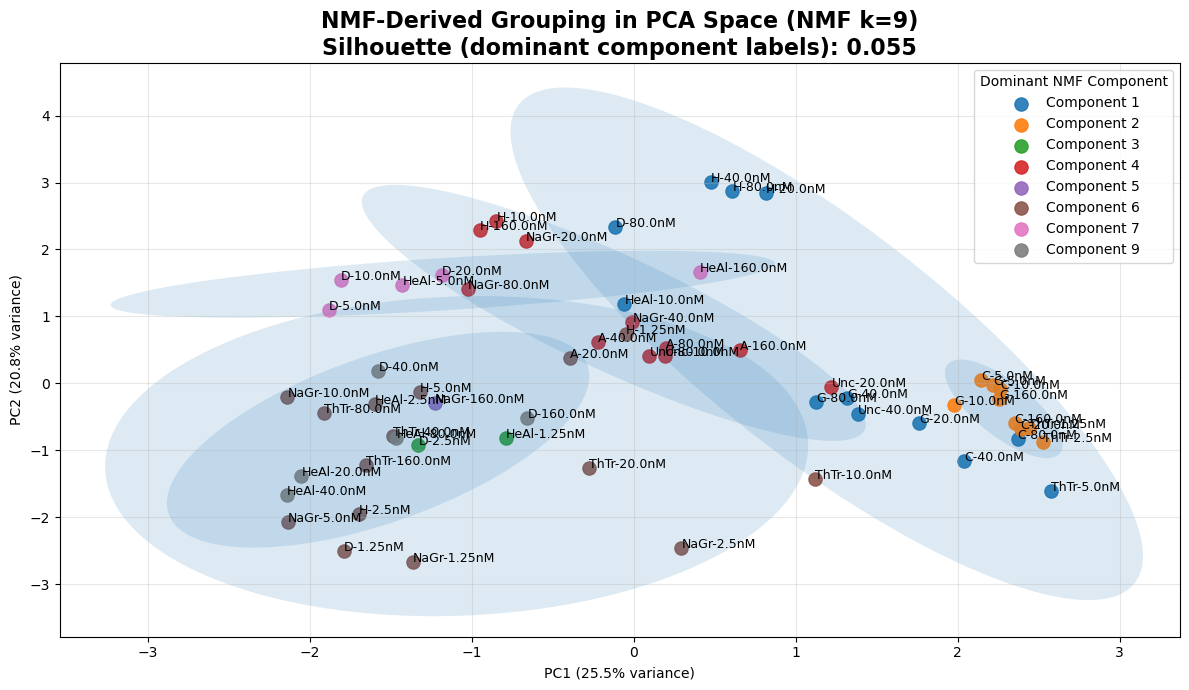

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from matplotlib.patches import Ellipse

# Behavior space: conditions × components
B = behavior_space_df.to_numpy(dtype=float)
names = behavior_space_df.index.astype(str).to_list()

# Standardize for metrics / PCA (do NOT cluster in PCA; PCA is for plotting only)
Bz = StandardScaler().fit_transform(B)

# Dominant component label (matches your “Component 1/2/3” style)
labels = np.argmax(B, axis=1)

# Silhouette computed in FULL behavior space (not PCA)
sil = silhouette_score(Bz, labels)

# PCA for plotting
pca = PCA(n_components=2, random_state=42)
emb2 = pca.fit_transform(Bz)

plot_df = pd.DataFrame({"x": emb2[:, 0], "y": emb2[:, 1], "label": labels}, index=names)

def add_ellipse(ax, pts, n_std=2.2, alpha=0.15):
    if pts.shape[0] < 3:
        return
    cov = np.cov(pts.T)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(np.maximum(vals, 1e-12))
    mean = pts.mean(axis=0)
    ell = Ellipse(xy=mean, width=width, height=height, angle=theta, alpha=alpha)
    ax.add_patch(ell)

fig, ax = plt.subplots(1, 1, figsize=(12, 7))

for c in np.unique(labels):
    sub = plot_df[plot_df["label"] == c]
    ax.scatter(sub["x"], sub["y"], s=90, alpha=0.9, label=f"Component {c+1}")
    add_ellipse(ax, sub[["x", "y"]].to_numpy(), n_std=2.2, alpha=0.15)

for name, row in plot_df.iterrows():
    ax.text(row["x"], row["y"], name, fontsize=9)

ax.set_title(
    f"NMF-Derived Grouping in PCA Space (NMF k={behavior_space_df.shape[1]})\n"
    f"Silhouette (dominant component labels): {sil:.3f}",
    fontweight="bold",
    fontsize=16
)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.grid(True, alpha=0.3)
ax.legend(title="Dominant NMF Component")
plt.tight_layout()
plt.show()

Multi-feature matrix ready:
  shape: (44658, 60) (rows=feature*time, cols=conditions)
  conditions: 60
  feature blocks: 9

Computing NMF reconstruction MSE across k...
  k= 2 -> MSE=0.6199
  k= 3 -> MSE=0.5618
  k= 4 -> MSE=0.5122
  k= 5 -> MSE=0.4722
  k= 6 -> MSE=0.4390
  k= 7 -> MSE=0.4149
  k= 8 -> MSE=0.3934
  k= 9 -> MSE=0.3733
  k=10 -> MSE=0.3568
  k=11 -> MSE=0.3403
  k=12 -> MSE=0.3245
  k=13 -> MSE=0.3092
  k=14 -> MSE=0.2962
  k=15 -> MSE=0.2846

Selected NMF rank (knee on log-MSE): k=6


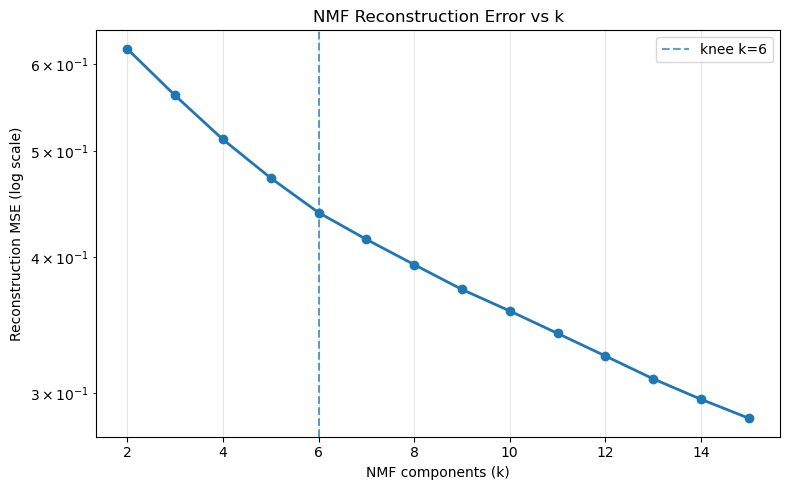


Final NMF fit:
  W shape: (44658, 6) (rows=feature*time, cols=k)
  H shape: (6, 60) (rows=k, cols=conditions)
  final MSE: 0.43899549843579305

(A) Dominant-component grouping
  groups: 5
  silhouette avg: 0.394441362321395
  group sizes: {0: 24, 1: 4, 2: 21, 4: 2, 5: 9}


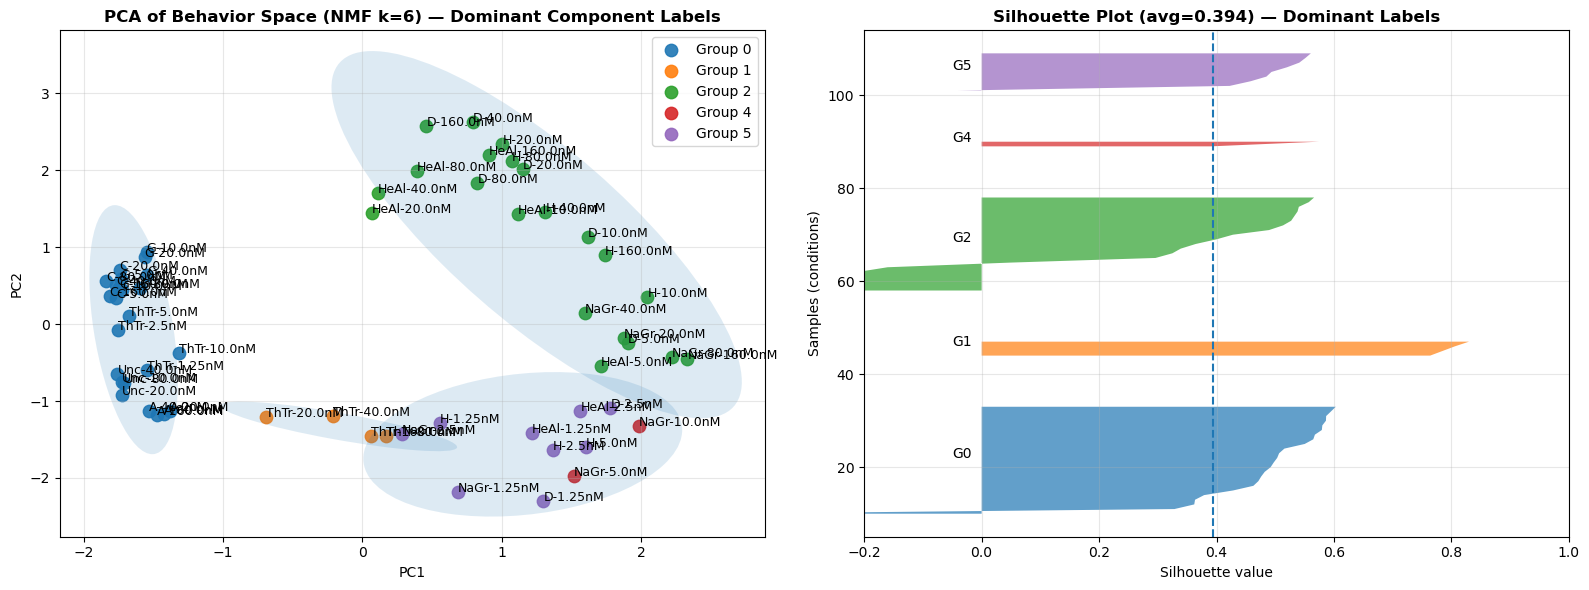


(B) KMeans clustering on behavior space
  tested ks: [(2, 0.342, [35, 25]), (3, 0.424, [21, 14, 25]), (4, 0.486, [14, 14, 18, 14]), (5, 0.523, [8, 14, 14, 13, 11]), (6, 0.605, [14, 8, 9, 5, 13, 11]), (7, 0.574, [12, 14, 11, 9, 5, 4, 5]), (8, 0.557, [9, 4, 14, 5, 12, 8, 5, 3])]
  chosen k: 6 (best=0.605, smallest within 0.02)
  silhouette avg: 0.6046125024014016
  cluster sizes: {0: 14, 1: 8, 2: 9, 3: 5, 4: 13, 5: 11}
  fraction negative silhouette: 0.0


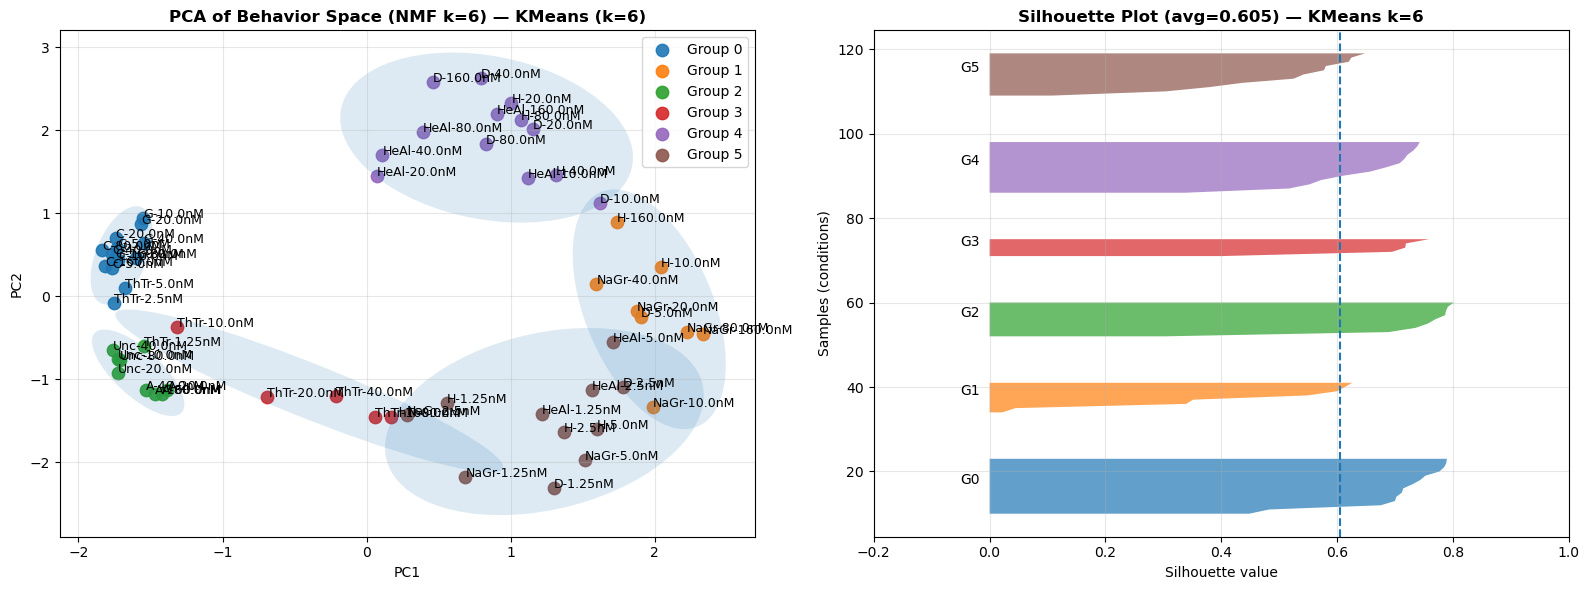


All outputs stored in `results` dict.
PCA explained variance: [0.35467175 0.27994747]


In [17]:
# ============================================================
# NMF behavior-space + BOTH grouping methods (dominant + KMeans)
# Produces:
#  (A) Dominant-component grouping: PCA scatter + silhouette plot + metrics
#  (B) KMeans clustering on behavior space: PCA scatter + silhouette plot + metrics
# Assumes you already have:
#   - df (long table with columns: 'time (s)', 'condition', and features below)
#   - multi_feature_matrix built as (feature_block*time) x conditions
#   - condition_columns = ordered list of conditions matching columns of matrix
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import NMF, PCA
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, silhouette_score, silhouette_samples
from matplotlib.patches import Ellipse

# -----------------------------
# 0) CONFIG
# -----------------------------
features_and_sigmas = {
    'velocity magnitude [m/s]_mean':   1.0,
    'vorticity [1/s]_mean':            1.5,
    'divergence [1/s]_mean':           1.5,
    'Protein Concentration_nM':        1.0,
    'Translation Rate [nM/s]':         1.0,
    'correlation length [m]_mean':     1.0,
    'distance [m]_mean':               0.0,

    # 'power [W]_mean':                  0.5,
    # 'shear [1/s]_mean':                1.0,
    # 'strain [1/s]_mean':               1.0,
    # 'velocity magnitude [m/s]_dt':     1.0,
    # 'correlation length [m]_dt':       1.0,
}

SIGNED_FEATURES = {
    'vorticity [1/s]_mean',
    'divergence [1/s]_mean',
}

APPLY_ZSCORE = True
NMF_MAX_COMPONENTS = 15
NMF_RANDOM_STATE = 42

# KMeans sweep constraints (important)
KMEANS_K_MIN = 2
KMEANS_MIN_CLUSTER_SIZE = 3
KMEANS_DELTA = 0.02  # choose smallest k within (best - delta)
KMEANS_N_INIT = 50

# -----------------------------
# 1) BUILD multi_feature_matrix
#     (feature_block*time) x conditions
# -----------------------------
features = list(features_and_sigmas.keys())
all_conditions = sorted(df['condition'].dropna().unique().tolist())

common_time_index = np.sort(df['time (s)'].dropna().unique())
common_time_index = pd.Index(common_time_index, name='time (s)')

def _interp_to_common_time(s: pd.Series, common_idx: pd.Index) -> pd.Series:
    """
    Interpolate ONLY within observed time range; outside -> NaN.
    """
    s = s.sort_index()
    s_valid = s.dropna()
    out = pd.Series(np.nan, index=common_idx, dtype=float)
    if s_valid.empty:
        return out

    x = s_valid.index.to_numpy(dtype=float)
    y = s_valid.to_numpy(dtype=float)
    t = common_idx.to_numpy(dtype=float)

    inside = (t >= x.min()) & (t <= x.max())
    if np.any(inside):
        out.iloc[np.where(inside)[0]] = np.interp(t[inside], x, y)
    return out

def _smooth_ignore_missing(col: pd.Series, sigma: float) -> pd.Series:
    """
    Smooth while respecting NaNs: fill temporarily for smoothing then restore NaNs.
    """
    if sigma <= 0:
        return col
    arr = col.to_numpy(dtype=float)
    nanmask = ~np.isfinite(arr)
    if nanmask.all():
        return col

    filled = pd.Series(arr).interpolate(limit_direction="both").to_numpy(dtype=float)
    sm = gaussian_filter1d(filled, sigma=float(sigma), mode="nearest")
    sm[nanmask] = np.nan
    return pd.Series(sm, index=col.index)

def _make_nonneg_for_nmf(mat: pd.DataFrame, feature_name: str) -> dict:
    """
    Signed features -> split pos/neg channels.
    Unsigned -> shift to >=0 if needed.
    """
    if feature_name in SIGNED_FEATURES:
        pos = mat.clip(lower=0)
        neg = (-mat).clip(lower=0)
        return {f"{feature_name}__pos": pos, f"{feature_name}__neg": neg}

    min_val = float(np.nanmin(mat.to_numpy()))
    if min_val < 0:
        mat = mat - min_val
    return {feature_name: mat}

expanded_feature_matrices = {}

for feature in features:
    pivot = df.pivot_table(
        index='time (s)',
        columns='condition',
        values=feature,
        aggfunc='mean'
    ).reindex(index=common_time_index, columns=all_conditions)

    interp = pd.DataFrame(index=common_time_index, columns=all_conditions, dtype=float)
    for c in all_conditions:
        interp[c] = _interp_to_common_time(pivot[c], common_time_index)

    sigma = float(features_and_sigmas[feature])
    if sigma > 0:
        for c in all_conditions:
            interp[c] = _smooth_ignore_missing(interp[c], sigma)

    # Fill remaining NaNs per-condition median (less biased than global median)
    if interp.isna().any().any():
        global_med = float(np.nanmedian(interp.to_numpy()))
        for c in interp.columns:
            col = interp[c]
            if col.isna().all():
                interp[c] = col.fillna(global_med)
            else:
                interp[c] = col.fillna(float(np.nanmedian(col.to_numpy())))

    parts = _make_nonneg_for_nmf(interp, feature)
    for name, mat in parts.items():
        expanded_feature_matrices[name] = mat

scaled_feature_matrices = {}
scalers = {}

if APPLY_ZSCORE:
    for feature_name, mat in expanded_feature_matrices.items():
        scaler = StandardScaler()
        X_block = scaler.fit_transform(mat.to_numpy(dtype=float))
        X_block = np.clip(X_block, -8, 8)  # guardrail
        min_val = float(X_block.min())
        if min_val < 0:
            X_block = X_block - min_val
        scaled_feature_matrices[feature_name] = X_block
        scalers[feature_name] = scaler
else:
    for feature_name, mat in expanded_feature_matrices.items():
        X_block = mat.to_numpy(dtype=float)
        min_val = float(X_block.min())
        if min_val < 0:
            X_block = X_block - min_val
        scaled_feature_matrices[feature_name] = X_block
        scalers[feature_name] = None

feature_names = list(scaled_feature_matrices.keys())
multi_feature_matrix = np.vstack([scaled_feature_matrices[name] for name in feature_names])

condition_columns = all_conditions
time_index = common_time_index

print("Multi-feature matrix ready:")
print("  shape:", multi_feature_matrix.shape, "(rows=feature*time, cols=conditions)")
print("  conditions:", len(condition_columns))
print("  feature blocks:", len(feature_names))

# -----------------------------
# 2) PICK NMF k via knee on log-MSE
# -----------------------------
X = np.asarray(multi_feature_matrix, dtype=float)
max_components = min(NMF_MAX_COMPONENTS, min(X.shape))

k_range = list(range(2, max_components + 1))
mse_list = []

def _nmf_mse(k: int) -> float:
    nmf = NMF(
        n_components=k,
        init="nndsvda",
        solver="cd",
        beta_loss="frobenius",
        max_iter=4000,
        tol=1e-5,
        random_state=NMF_RANDOM_STATE
    )
    W = nmf.fit_transform(X)
    H = nmf.components_
    Xhat = W @ H
    return mean_squared_error(X.ravel(), Xhat.ravel())

print("\nComputing NMF reconstruction MSE across k...")
for k in k_range:
    mse = _nmf_mse(k)
    mse_list.append(mse)
    print(f"  k={k:2d} -> MSE={mse:.4f}")

def knee_by_chord(x_list, y_list):
    x = np.asarray(x_list, float)
    y = np.asarray(y_list, float)
    y = np.log(np.maximum(y, 1e-12))
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    v = p2 - p1
    v = v / (np.linalg.norm(v) + 1e-12)
    pts = np.c_[x, y]
    proj = ((pts - p1) @ v)
    orth = (pts - p1) - np.outer(proj, v)
    d = np.linalg.norm(orth, axis=1)
    return int(x[np.argmax(d)])

nmf_k = knee_by_chord(k_range, mse_list)

print(f"\nSelected NMF rank (knee on log-MSE): k={nmf_k}")

plt.figure(figsize=(8, 5))
plt.plot(k_range, mse_list, "o-", linewidth=2)
plt.yscale("log")
plt.axvline(nmf_k, linestyle="--", alpha=0.7, label=f"knee k={nmf_k}")
plt.xlabel("NMF components (k)")
plt.ylabel("Reconstruction MSE (log scale)")
plt.title("NMF Reconstruction Error vs k")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 3) FIT FINAL NMF with selected k
# -----------------------------
nmf = NMF(
    n_components=nmf_k,
    init="nndsvda",
    solver="cd",
    beta_loss="frobenius",
    max_iter=4000,
    tol=1e-5,
    random_state=NMF_RANDOM_STATE
)
W = nmf.fit_transform(X)
H = nmf.components_
Xhat = W @ H
final_mse = mean_squared_error(X.ravel(), Xhat.ravel())

print("\nFinal NMF fit:")
print("  W shape:", W.shape, "(rows=feature*time, cols=k)")
print("  H shape:", H.shape, "(rows=k, cols=conditions)")
print("  final MSE:", final_mse)

# Behavior space coordinates (conditions x k)
behavior_space = H.T
behavior_space_df = pd.DataFrame(
    behavior_space,
    index=condition_columns,
    columns=[f"comp_{i+1}" for i in range(nmf_k)]
)

# -----------------------------
# 4) HELPERS for plots
# -----------------------------
def add_ellipse(ax, pts, n_std=2.2, alpha=0.15):
    if pts.shape[0] < 3:
        return
    cov = np.cov(pts.T)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(np.maximum(vals, 1e-12))
    mean = pts.mean(axis=0)
    ell = Ellipse(xy=mean, width=width, height=height, angle=theta, alpha=alpha)
    ax.add_patch(ell)

def plot_scatter_and_silhouette(title_left, title_right, names, emb2, labels, sil_vals, sil_avg, show_ellipses=True):
    fig, (ax_scatter, ax_sil) = plt.subplots(1, 2, figsize=(16, 6))

    # scatter
    for c in np.unique(labels):
        idx = labels == c
        ax_scatter.scatter(emb2[idx, 0], emb2[idx, 1], s=80, alpha=0.9, label=f"Group {c}")
        if show_ellipses:
            add_ellipse(ax_scatter, emb2[idx, :], n_std=2.2, alpha=0.15)

    for i, name in enumerate(names):
        ax_scatter.text(emb2[i, 0], emb2[i, 1], name, fontsize=9)

    ax_scatter.set_title(title_left, fontweight="bold")
    ax_scatter.set_xlabel("PC1")
    ax_scatter.set_ylabel("PC2")
    ax_scatter.grid(True, alpha=0.3)
    ax_scatter.legend()

    # silhouette plot
    y_lower = 10
    for c in np.unique(labels):
        vals = np.sort(sil_vals[labels == c])
        size = len(vals)
        y_upper = y_lower + size
        ax_sil.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7)
        ax_sil.text(-0.05, y_lower + 0.5 * size, f"G{c}", fontsize=10)
        y_lower = y_upper + 10

    ax_sil.axvline(sil_avg, linestyle="--")
    ax_sil.set_title(title_right, fontweight="bold")
    ax_sil.set_xlabel("Silhouette value")
    ax_sil.set_ylabel("Samples (conditions)")
    ax_sil.set_xlim(-0.2, 1.0)
    ax_sil.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Standardize behavior space for metrics + PCA (PCA is for visualization only)
B = behavior_space_df.to_numpy(dtype=float)
names = behavior_space_df.index.astype(str).to_list()
Bz = StandardScaler().fit_transform(B)

pca = PCA(n_components=2, random_state=42)
emb2 = pca.fit_transform(Bz)

# -----------------------------
# 5A) METHOD A: Dominant-component grouping (NOT KMeans)
# -----------------------------
labels_dom = np.argmax(B, axis=1)
sil_dom = silhouette_samples(Bz, labels_dom)
sil_dom_avg = float(np.mean(sil_dom))

print("\n(A) Dominant-component grouping")
print("  groups:", len(np.unique(labels_dom)))
print("  silhouette avg:", sil_dom_avg)
print("  group sizes:", dict(pd.Series(labels_dom).value_counts().sort_index()))

plot_scatter_and_silhouette(
    title_left=f"PCA of Behavior Space (NMF k={nmf_k}) — Dominant Component Labels",
    title_right=f"Silhouette Plot (avg={sil_dom_avg:.3f}) — Dominant Labels",
    names=names,
    emb2=emb2,
    labels=labels_dom,
    sil_vals=sil_dom,
    sil_avg=sil_dom_avg,
    show_ellipses=True
)

# -----------------------------
# 5B) METHOD B: KMeans clustering on behavior space
#     with constraints + parsimonious selection
# -----------------------------
n = Bz.shape[0]
k_max = min(8, n // KMEANS_MIN_CLUSTER_SIZE)  # hard cap and min-size cap
k_min = KMEANS_K_MIN

kmeans_candidates = []
kmeans_models = {}

for k in range(k_min, k_max + 1):
    km = KMeans(n_clusters=k, n_init=KMEANS_N_INIT, random_state=42)
    lab = km.fit_predict(Bz)
    counts = np.bincount(lab, minlength=k)
    if counts.min() < KMEANS_MIN_CLUSTER_SIZE:
        continue
    s = silhouette_score(Bz, lab)
    kmeans_candidates.append((k, float(s), counts))
    kmeans_models[k] = (km, lab)

if not kmeans_candidates:
    raise ValueError("No KMeans k satisfied MIN_CLUSTER_SIZE. Lower KMEANS_MIN_CLUSTER_SIZE or increase samples.")

best_k, best_s, _ = max(kmeans_candidates, key=lambda t: t[1])
close_ks = [k for (k, s, _) in kmeans_candidates if s >= best_s - KMEANS_DELTA]
k_kmeans = min(close_ks)

km, labels_km = kmeans_models[k_kmeans]
sil_km = silhouette_samples(Bz, labels_km)
sil_km_avg = float(np.mean(sil_km))

print("\n(B) KMeans clustering on behavior space")
print("  tested ks:", [(k, round(s, 3), c.tolist()) for (k, s, c) in sorted(kmeans_candidates, key=lambda t: t[0])])
print("  chosen k:", k_kmeans, f"(best={best_s:.3f}, smallest within {KMEANS_DELTA:.2f})")
print("  silhouette avg:", sil_km_avg)
print("  cluster sizes:", dict(pd.Series(labels_km).value_counts().sort_index()))
print("  fraction negative silhouette:", float(np.mean(sil_km < 0)))

plot_scatter_and_silhouette(
    title_left=f"PCA of Behavior Space (NMF k={nmf_k}) — KMeans (k={k_kmeans})",
    title_right=f"Silhouette Plot (avg={sil_km_avg:.3f}) — KMeans k={k_kmeans}",
    names=names,
    emb2=emb2,
    labels=labels_km,
    sil_vals=sil_km,
    sil_avg=sil_km_avg,
    show_ellipses=True
)

# -----------------------------
# 6) OUTPUTS you can use later
# -----------------------------
results = {
    "nmf_k": nmf_k,
    "W": W,
    "H": H,
    "behavior_space_df": behavior_space_df,
    "behavior_space_z": Bz,
    "pca_2d": emb2,
    "pca_explained_var": pca.explained_variance_ratio_,
    "dominant_labels": labels_dom,
    "dominant_silhouette_avg": sil_dom_avg,
    "dominant_silhouette_values": sil_dom,
    "kmeans_k": k_kmeans,
    "kmeans_labels": labels_km,
    "kmeans_silhouette_avg": sil_km_avg,
    "kmeans_silhouette_values": sil_km,
}

print("\nAll outputs stored in `results` dict.")
print("PCA explained variance:", results["pca_explained_var"])

In [18]:
behavior_space_df

,comp_1,comp_2,comp_3,comp_4,comp_5,comp_6
A-160.0nM,20.417577,5.578888,9.616718,0.000000,0.000000,1.993724
A-20.0nM,19.314133,5.615082,9.586994,0.253573,0.000000,2.224783
A-40.0nM,20.475043,5.522721,9.019749,0.248793,0.000000,1.962609
A-80.0nM,19.562170,5.883222,10.428610,0.000000,0.000000,1.844366
C-10.0nM,22.407576,0.000000,0.001994,4.610943,0.752658,4.325245
C-160.0nM,23.315357,0.228811,1.010776,4.181085,0.557163,3.929614
C-20.0nM,20.885038,0.000000,0.000000,5.438348,1.134484,3.908180
C-40.0nM,21.576313,0.314949,0.000000,4.935613,1.048965,3.846423
C-5.0nM,21.755237,0.860015,1.477469,4.334111,0.548189,3.756276
C-80.0nM,22.518796,0.000000,0.080667,4.896435,0.802296,3.912226


Building feature blocks (parallel threads, n_jobs=7)...
Multi-feature matrix ready:
  shape: (44658, 60) (rows=feature*time, cols=conditions)
  conditions: 60
  feature blocks: 9

Computing NMF reconstruction MSE across k (parallel threads, n_jobs=7)...
  k= 2 -> MSE=0.6199
  k= 3 -> MSE=0.5618
  k= 4 -> MSE=0.5122
  k= 5 -> MSE=0.4722
  k= 6 -> MSE=0.4390
  k= 7 -> MSE=0.4149
  k= 8 -> MSE=0.3934
  k= 9 -> MSE=0.3733
  k=10 -> MSE=0.3568
  k=11 -> MSE=0.3403
  k=12 -> MSE=0.3245
  k=13 -> MSE=0.3092
  k=14 -> MSE=0.2962
  k=15 -> MSE=0.2846

Selected NMF rank (knee on log-MSE): k=6


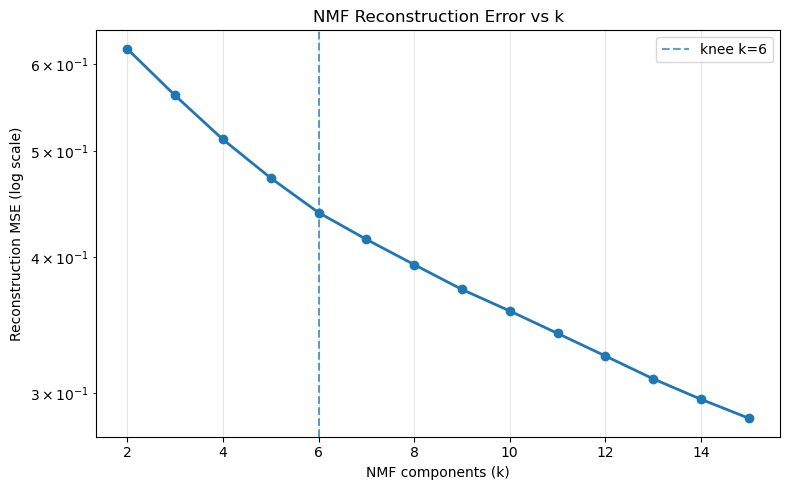


Final NMF fit:
  W shape: (44658, 6) (rows=feature*time, cols=k)
  H shape: (6, 60) (rows=k, cols=conditions)
  final MSE: 0.43899549843579305

(A) Dominant-component grouping (diagnostic only)
  groups: 5
  silhouette avg (z-scored behavior space): 0.394441362321395
  group sizes: {0: 24, 1: 4, 2: 21, 4: 2, 5: 9}


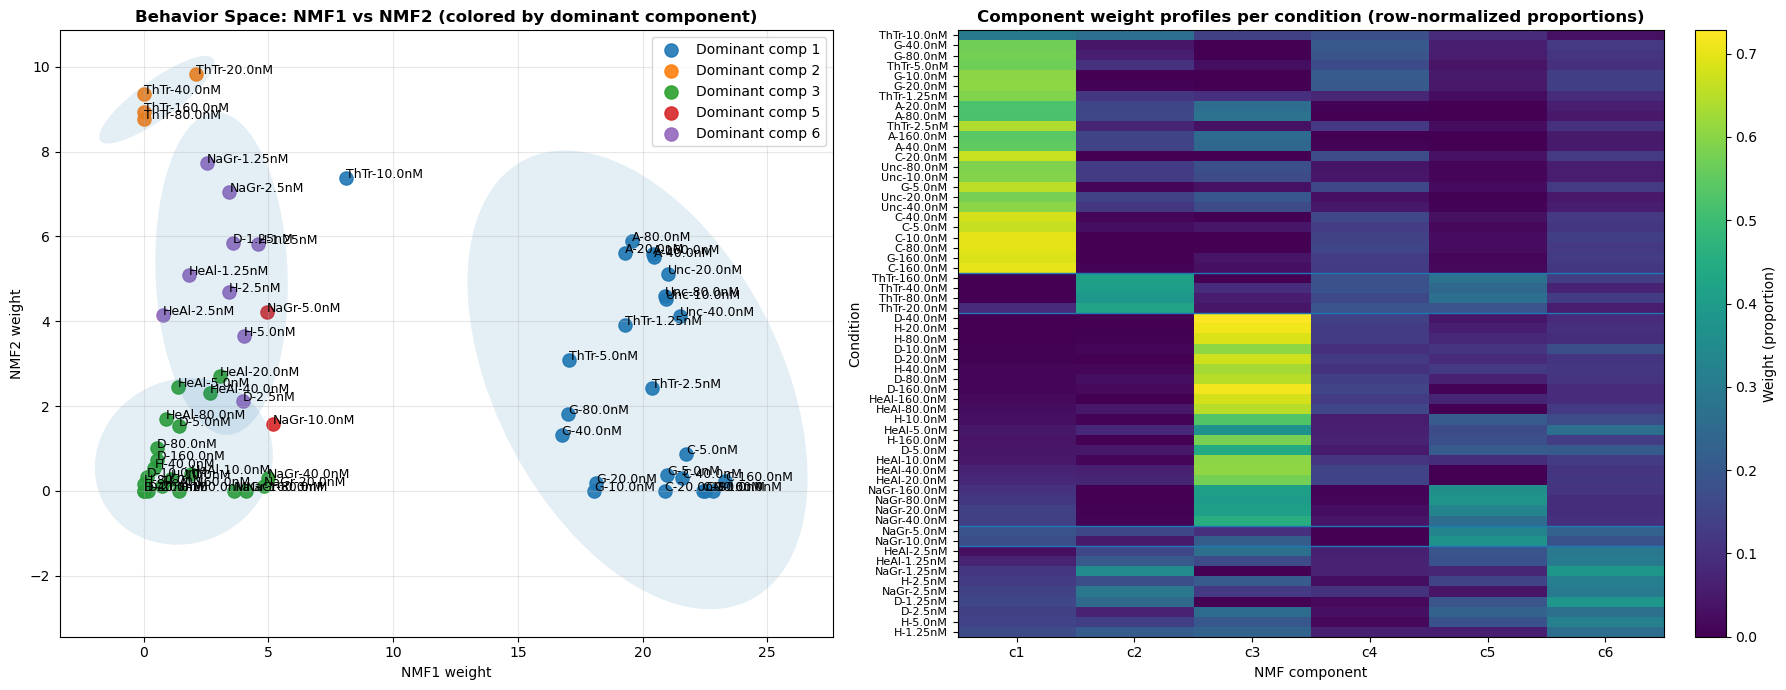


(B) KMeans clustering on behavior space
  tested ks: [(2, 0.342, [35, 25]), (3, 0.424, [21, 14, 25]), (4, 0.486, [14, 14, 18, 14]), (5, 0.523, [8, 14, 14, 13, 11]), (6, 0.605, [14, 8, 9, 5, 13, 11]), (7, 0.574, [12, 14, 11, 9, 5, 4, 5]), (8, 0.557, [9, 4, 14, 5, 12, 8, 5, 3])]
  chosen k: 6 (best=0.605, smallest within 0.02)
  silhouette avg: 0.6046125024014016
  cluster sizes: {0: 14, 1: 8, 2: 9, 3: 5, 4: 13, 5: 11}
  fraction negative silhouette: 0.0


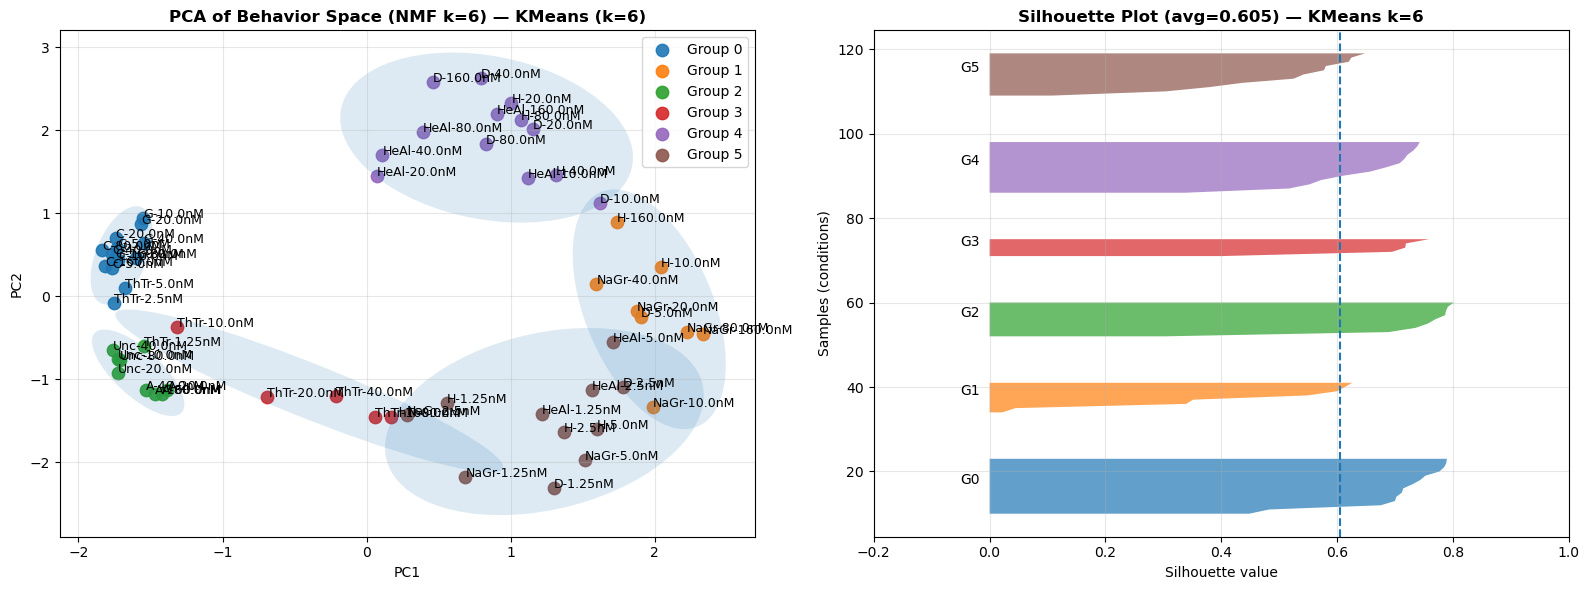


All outputs stored in `results` dict.
PCA explained variance: [0.35467175 0.27994747]


In [19]:
# ============================================================
# NMF behavior-space + BOTH grouping methods (dominant + KMeans)
# FAST + SAFE PARALLEL VERSION (threads; avoids loky memory blowups)
#
# Produces:
#  (A) Dominant-component grouping:
#       - Left: NMF1 vs NMF2 scatter (behavior-space coords) colored by dominant component
#       - Right: heatmap of component weights per condition (row-normalized proportions)
#  (B) KMeans clustering on behavior space:
#       - PCA scatter + silhouette plot + metrics
#
# Requires:
#   - df with columns: 'time (s)', 'condition', plus the features listed below
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter1d
from joblib import Parallel, delayed
from threadpoolctl import threadpool_limits

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import NMF, PCA
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, silhouette_score, silhouette_samples
from matplotlib.patches import Ellipse

# -----------------------------
# 0) CONFIG
# -----------------------------
features_and_sigmas = {
    'velocity magnitude [m/s]_mean':   1.0,
    'vorticity [1/s]_mean':            1.5,
    'divergence [1/s]_mean':           1.5,
    'Protein Concentration_nM':        1.0,
    'Translation Rate [nM/s]':         1.0,
    'correlation length [m]_mean':     1.0,
    'distance [m]_mean':               0.0,

    # 'power [W]_mean':                  0.5,
    # 'shear [1/s]_mean':                1.0,
    # 'strain [1/s]_mean':               1.0,
    # 'velocity magnitude [m/s]_dt':     1.0,
    # 'correlation length [m]_dt':       1.0,
}

SIGNED_FEATURES = {
    'vorticity [1/s]_mean',
    'divergence [1/s]_mean',
}

APPLY_ZSCORE = True
NMF_MAX_COMPONENTS = 15
NMF_RANDOM_STATE = 42

# NMF speed knobs
SWEEP_MAX_ITER = 1500   # faster sweep
FINAL_MAX_ITER = 4000   # accurate final fit

# Parallel controls (THREADS, not PROCESSES)
N_JOBS = min(len(features_and_sigmas), os.cpu_count() or 4)  # safe default
JOBLIB_BACKEND = "threading"  # CRITICAL: avoids df/X duplication

# KMeans sweep constraints
KMEANS_K_MIN = 2
KMEANS_MIN_CLUSTER_SIZE = 3
KMEANS_DELTA = 0.02
KMEANS_N_INIT = 50

# -----------------------------
# 1) BUILD multi_feature_matrix
#     (feature_block*time) x conditions
#     (thread-parallel over features)
# -----------------------------
features = list(features_and_sigmas.keys())
all_conditions = sorted(df['condition'].dropna().unique().tolist())

common_time_index = np.sort(df['time (s)'].dropna().unique())
common_time_index = pd.Index(common_time_index, name='time (s)')

def _interp_to_common_time(s: pd.Series, common_idx: pd.Index) -> pd.Series:
    """Interpolate ONLY within observed time range; outside -> NaN."""
    s = s.sort_index()
    s_valid = s.dropna()
    out = pd.Series(np.nan, index=common_idx, dtype=float)
    if s_valid.empty:
        return out

    x = s_valid.index.to_numpy(dtype=float)
    y = s_valid.to_numpy(dtype=float)
    t = common_idx.to_numpy(dtype=float)

    inside = (t >= x.min()) & (t <= x.max())
    if np.any(inside):
        out.iloc[np.where(inside)[0]] = np.interp(t[inside], x, y)
    return out

def _smooth_ignore_missing(col: pd.Series, sigma: float) -> pd.Series:
    """Smooth while respecting NaNs: fill temporarily for smoothing then restore NaNs."""
    if sigma <= 0:
        return col
    arr = col.to_numpy(dtype=float)
    nanmask = ~np.isfinite(arr)
    if nanmask.all():
        return col

    filled = pd.Series(arr).interpolate(limit_direction="both").to_numpy(dtype=float)
    sm = gaussian_filter1d(filled, sigma=float(sigma), mode="nearest")
    sm[nanmask] = np.nan
    return pd.Series(sm, index=col.index)

def _make_nonneg_for_nmf(mat: pd.DataFrame, feature_name: str) -> dict:
    """
    NMF requires nonnegative input.
    Signed features -> split pos/neg channels.
    Unsigned -> shift to >=0 if needed.
    """
    if feature_name in SIGNED_FEATURES:
        pos = mat.clip(lower=0)
        neg = (-mat).clip(lower=0)
        return {f"{feature_name}__pos": pos, f"{feature_name}__neg": neg}

    min_val = float(np.nanmin(mat.to_numpy()))
    if min_val < 0:
        mat = mat - min_val
    return {feature_name: mat}

def _build_feature_parts(feature: str) -> dict:
    pivot = df.pivot_table(
        index='time (s)',
        columns='condition',
        values=feature,
        aggfunc='mean'
    ).reindex(index=common_time_index, columns=all_conditions)

    interp = pd.DataFrame(index=common_time_index, columns=all_conditions, dtype=float)
    for c in all_conditions:
        interp[c] = _interp_to_common_time(pivot[c], common_time_index)

    sigma = float(features_and_sigmas[feature])
    if sigma > 0:
        for c in all_conditions:
            interp[c] = _smooth_ignore_missing(interp[c], sigma)

    # Fill remaining NaNs per-condition median
    if interp.isna().any().any():
        global_med = float(np.nanmedian(interp.to_numpy()))
        for c in interp.columns:
            col = interp[c]
            if col.isna().all():
                interp[c] = col.fillna(global_med)
            else:
                interp[c] = col.fillna(float(np.nanmedian(col.to_numpy())))

    return _make_nonneg_for_nmf(interp, feature)

print(f"Building feature blocks (parallel threads, n_jobs={N_JOBS})...")
with threadpool_limits(limits=1):  # avoids BLAS oversubscription
    parts_list = Parallel(n_jobs=N_JOBS, backend=JOBLIB_BACKEND)(
        delayed(_build_feature_parts)(f) for f in features
    )

expanded_feature_matrices = {}
for parts in parts_list:
    expanded_feature_matrices.update(parts)

scaled_feature_matrices = {}
scalers = {}

if APPLY_ZSCORE:
    for feature_name, mat in expanded_feature_matrices.items():
        scaler = StandardScaler()
        X_block = scaler.fit_transform(mat.to_numpy(dtype=float))
        X_block = np.clip(X_block, -8, 8)
        min_val = float(X_block.min())
        if min_val < 0:
            X_block = X_block - min_val
        scaled_feature_matrices[feature_name] = X_block
        scalers[feature_name] = scaler
else:
    for feature_name, mat in expanded_feature_matrices.items():
        X_block = mat.to_numpy(dtype=float)
        min_val = float(X_block.min())
        if min_val < 0:
            X_block = X_block - min_val
        scaled_feature_matrices[feature_name] = X_block
        scalers[feature_name] = None

feature_names = list(scaled_feature_matrices.keys())
multi_feature_matrix = np.vstack([scaled_feature_matrices[name] for name in feature_names])

condition_columns = all_conditions
time_index = common_time_index

print("Multi-feature matrix ready:")
print("  shape:", multi_feature_matrix.shape, "(rows=feature*time, cols=conditions)")
print("  conditions:", len(condition_columns))
print("  feature blocks:", len(feature_names))

# -----------------------------
# 2) PICK NMF k via knee on log-MSE
#     (thread-parallel over k)
# -----------------------------
X = np.asarray(multi_feature_matrix, dtype=float)
max_components = min(NMF_MAX_COMPONENTS, min(X.shape))
k_range = list(range(2, max_components + 1))

def _nmf_mse(k: int) -> tuple[int, float]:
    nmf = NMF(
        n_components=k,
        init="nndsvda",
        solver="cd",
        beta_loss="frobenius",
        max_iter=SWEEP_MAX_ITER,
        tol=1e-5,
        random_state=NMF_RANDOM_STATE
    )
    Wk = nmf.fit_transform(X)
    Hk = nmf.components_
    Xhat = Wk @ Hk
    mse = mean_squared_error(X.ravel(), Xhat.ravel())
    return k, float(mse)

print(f"\nComputing NMF reconstruction MSE across k (parallel threads, n_jobs={min(N_JOBS, len(k_range))})...")
with threadpool_limits(limits=1):
    pairs = Parallel(n_jobs=min(N_JOBS, len(k_range)), backend=JOBLIB_BACKEND)(
        delayed(_nmf_mse)(k) for k in k_range
    )

pairs.sort(key=lambda t: t[0])
k_range = [k for k, _ in pairs]
mse_list = [mse for _, mse in pairs]

for k, mse in pairs:
    print(f"  k={k:2d} -> MSE={mse:.4f}")

def knee_by_chord(x_list, y_list):
    x = np.asarray(x_list, float)
    y = np.asarray(y_list, float)
    y = np.log(np.maximum(y, 1e-12))
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    v = p2 - p1
    v = v / (np.linalg.norm(v) + 1e-12)
    pts = np.c_[x, y]
    proj = ((pts - p1) @ v)
    orth = (pts - p1) - np.outer(proj, v)
    d = np.linalg.norm(orth, axis=1)
    return int(x[np.argmax(d)])

nmf_k = knee_by_chord(k_range, mse_list)
print(f"\nSelected NMF rank (knee on log-MSE): k={nmf_k}")

plt.figure(figsize=(8, 5))
plt.plot(k_range, mse_list, "o-", linewidth=2)
plt.yscale("log")
plt.axvline(nmf_k, linestyle="--", alpha=0.7, label=f"knee k={nmf_k}")
plt.xlabel("NMF components (k)")
plt.ylabel("Reconstruction MSE (log scale)")
plt.title("NMF Reconstruction Error vs k")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 3) FIT FINAL NMF with selected k
# -----------------------------
nmf = NMF(
    n_components=nmf_k,
    init="nndsvda",
    solver="cd",
    beta_loss="frobenius",
    max_iter=FINAL_MAX_ITER,
    tol=1e-5,
    random_state=NMF_RANDOM_STATE
)
W = nmf.fit_transform(X)
H = nmf.components_
Xhat = W @ H
final_mse = mean_squared_error(X.ravel(), Xhat.ravel())

print("\nFinal NMF fit:")
print("  W shape:", W.shape, "(rows=feature*time, cols=k)")
print("  H shape:", H.shape, "(rows=k, cols=conditions)")
print("  final MSE:", final_mse)

behavior_space = H.T  # (conditions, k)
behavior_space_df = pd.DataFrame(
    behavior_space,
    index=condition_columns,
    columns=[f"comp_{i+1}" for i in range(nmf_k)]
)

# -----------------------------
# 4) HELPERS for plots
# -----------------------------
def add_ellipse(ax, pts, n_std=2.2, alpha=0.15):
    if pts.shape[0] < 3:
        return
    cov = np.cov(pts.T)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(np.maximum(vals, 1e-12))
    mean = pts.mean(axis=0)
    ell = Ellipse(xy=mean, width=width, height=height, angle=theta, alpha=alpha)
    ax.add_patch(ell)

def plot_nmf12_and_weights(names, B, labels_dom, normalize_rows=True):
    if B.shape[1] < 2:
        raise ValueError(f"Need at least 2 NMF components. Got k={B.shape[1]}")

    nmf_xy = B[:, :2]

    order = np.lexsort((nmf_xy[:, 0], labels_dom))
    names_s = [names[i] for i in order]
    labels_s = labels_dom[order]
    mat = B[order, :].copy()

    if normalize_rows:
        mat = mat / (mat.sum(axis=1, keepdims=True) + 1e-12)

    fig, (ax_sc, ax_hm) = plt.subplots(1, 2, figsize=(18, 7))

    for g in np.unique(labels_dom):
        idx = labels_dom == g
        ax_sc.scatter(nmf_xy[idx, 0], nmf_xy[idx, 1], s=90, alpha=0.9, label=f"Dominant comp {g+1}")
        add_ellipse(ax_sc, nmf_xy[idx, :], n_std=2.2, alpha=0.12)

    for i, name in enumerate(names):
        ax_sc.text(nmf_xy[i, 0], nmf_xy[i, 1], name, fontsize=9)

    ax_sc.set_title("Behavior Space: NMF1 vs NMF2 (colored by dominant component)", fontweight="bold")
    ax_sc.set_xlabel("NMF1 weight")
    ax_sc.set_ylabel("NMF2 weight")
    ax_sc.grid(True, alpha=0.3)
    ax_sc.legend(loc="best")

    im = ax_hm.imshow(mat, aspect="auto", interpolation="nearest")
    ax_hm.set_title(
        "Component weight profiles per condition"
        + (" (row-normalized proportions)" if normalize_rows else " (raw weights)"),
        fontweight="bold"
    )
    ax_hm.set_xlabel("NMF component")
    ax_hm.set_ylabel("Condition")
    ax_hm.set_xticks(np.arange(B.shape[1]))
    ax_hm.set_xticklabels([f"c{i+1}" for i in range(B.shape[1])], rotation=0)
    ax_hm.set_yticks(np.arange(len(names_s)))
    ax_hm.set_yticklabels(names_s, fontsize=8)

    change_rows = np.where(np.diff(labels_s) != 0)[0]
    for r in change_rows:
        ax_hm.axhline(r + 0.5, linewidth=1.0)

    cbar = plt.colorbar(im, ax=ax_hm, fraction=0.046, pad=0.04)
    cbar.set_label("Weight" + (" (proportion)" if normalize_rows else ""))

    plt.tight_layout()
    plt.show()

def plot_scatter_and_silhouette(title_left, title_right, names, emb2, labels, sil_vals, sil_avg, show_ellipses=True):
    fig, (ax_scatter, ax_sil) = plt.subplots(1, 2, figsize=(16, 6))

    for c in np.unique(labels):
        idx = labels == c
        ax_scatter.scatter(emb2[idx, 0], emb2[idx, 1], s=80, alpha=0.9, label=f"Group {c}")
        if show_ellipses:
            add_ellipse(ax_scatter, emb2[idx, :], n_std=2.2, alpha=0.15)

    for i, name in enumerate(names):
        ax_scatter.text(emb2[i, 0], emb2[i, 1], name, fontsize=9)

    ax_scatter.set_title(title_left, fontweight="bold")
    ax_scatter.set_xlabel("PC1")
    ax_scatter.set_ylabel("PC2")
    ax_scatter.grid(True, alpha=0.3)
    ax_scatter.legend()

    y_lower = 10
    for c in np.unique(labels):
        vals = np.sort(sil_vals[labels == c])
        size = len(vals)
        y_upper = y_lower + size
        ax_sil.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7)
        ax_sil.text(-0.05, y_lower + 0.5 * size, f"G{c}", fontsize=10)
        y_lower = y_upper + 10

    ax_sil.axvline(sil_avg, linestyle="--")
    ax_sil.set_title(title_right, fontweight="bold")
    ax_sil.set_xlabel("Silhouette value")
    ax_sil.set_ylabel("Samples (conditions)")
    ax_sil.set_xlim(-0.2, 1.0)
    ax_sil.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# -----------------------------
# 5A) Dominant-component grouping
# -----------------------------
B = behavior_space_df.to_numpy(dtype=float)
names = behavior_space_df.index.astype(str).to_list()
labels_dom = np.argmax(B, axis=1)

Bz = StandardScaler().fit_transform(B)
sil_dom = silhouette_samples(Bz, labels_dom)
sil_dom_avg = float(np.mean(sil_dom))
print("\n(A) Dominant-component grouping (diagnostic only)")
print("  groups:", len(np.unique(labels_dom)))
print("  silhouette avg (z-scored behavior space):", sil_dom_avg)
print("  group sizes:", dict(pd.Series(labels_dom).value_counts().sort_index()))

plot_nmf12_and_weights(names=names, B=B, labels_dom=labels_dom, normalize_rows=True)

# -----------------------------
# 5B) KMeans clustering on behavior space
# -----------------------------
pca = PCA(n_components=2, random_state=42)
emb2 = pca.fit_transform(Bz)

n = Bz.shape[0]
k_max = min(8, n // KMEANS_MIN_CLUSTER_SIZE)
k_min = KMEANS_K_MIN

kmeans_candidates = []
kmeans_models = {}

for k in range(k_min, k_max + 1):
    km = KMeans(n_clusters=k, n_init=KMEANS_N_INIT, random_state=42)
    lab = km.fit_predict(Bz)
    counts = np.bincount(lab, minlength=k)
    if counts.min() < KMEANS_MIN_CLUSTER_SIZE:
        continue
    s = silhouette_score(Bz, lab)
    kmeans_candidates.append((k, float(s), counts))
    kmeans_models[k] = (km, lab)

if not kmeans_candidates:
    raise ValueError("No KMeans k satisfied MIN_CLUSTER_SIZE. Lower KMEANS_MIN_CLUSTER_SIZE or increase samples.")

best_k, best_s, _ = max(kmeans_candidates, key=lambda t: t[1])
close_ks = [k for (k, s, _) in kmeans_candidates if s >= best_s - KMEANS_DELTA]
k_kmeans = min(close_ks)

km, labels_km = kmeans_models[k_kmeans]
sil_km = silhouette_samples(Bz, labels_km)
sil_km_avg = float(np.mean(sil_km))

print("\n(B) KMeans clustering on behavior space")
print("  tested ks:", [(k, round(s, 3), c.tolist()) for (k, s, c) in sorted(kmeans_candidates, key=lambda t: t[0])])
print("  chosen k:", k_kmeans, f"(best={best_s:.3f}, smallest within {KMEANS_DELTA:.2f})")
print("  silhouette avg:", sil_km_avg)
print("  cluster sizes:", dict(pd.Series(labels_km).value_counts().sort_index()))
print("  fraction negative silhouette:", float(np.mean(sil_km < 0)))

plot_scatter_and_silhouette(
    title_left=f"PCA of Behavior Space (NMF k={nmf_k}) — KMeans (k={k_kmeans})",
    title_right=f"Silhouette Plot (avg={sil_km_avg:.3f}) — KMeans k={k_kmeans}",
    names=names,
    emb2=emb2,
    labels=labels_km,
    sil_vals=sil_km,
    sil_avg=sil_km_avg,
    show_ellipses=True
)

# -----------------------------
# 6) OUTPUTS
# -----------------------------
results = {
    "nmf_k": nmf_k,
    "W": W,
    "H": H,
    "behavior_space_df": behavior_space_df,
    "behavior_space_z": Bz,
    "pca_2d": emb2,
    "pca_explained_var": pca.explained_variance_ratio_,
    "dominant_labels": labels_dom,
    "dominant_silhouette_avg": sil_dom_avg,
    "dominant_silhouette_values": sil_dom,
    "kmeans_k": k_kmeans,
    "kmeans_labels": labels_km,
    "kmeans_silhouette_avg": sil_km_avg,
    "kmeans_silhouette_values": sil_km,
}

print("\nAll outputs stored in `results` dict.")
print("PCA explained variance:", results["pca_explained_var"])